# Building Models from Provided Files

First, let's import the necessary modules from the provided files.

In [1]:
!pip install nba_api

import config
import collect_players
import collect_data

print("Files imported successfully.")

Files imported successfully.


### Exploring `config.py`

Let's inspect the contents of the `config.py` file to understand its configuration settings.

In [2]:
import inspect

try:
    print(inspect.getsource(config))
except TypeError:
    print("Could not get source for config.py. It might not be a module or is compiled.")

"""
Configuration constants for NBA Fantasy data collection.
"""

from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────

BASE_DIR = Path(__file__).parent
DATA_DIR = BASE_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

# Output files
HISTORICAL_GAMES_CSV = DATA_DIR / "nba_historical_games.csv"
PLAYER_GAME_LOGS_CSV = DATA_DIR / "nba_player_game_logs.csv"

# Ensure directories exist
DATA_DIR.mkdir(exist_ok=True)
RAW_DATA_DIR.mkdir(exist_ok=True)

# ── Data Collection ──────────────────────────────────────────────────────────

START_SEASON = 2000  # First season to collect (2000 = 1999-2000 season)
END_SEASON = 2026    # Last season to collect (2026 = 2025-2026 season)

# Rate limiting for NBA API
NBA_API_DELAY = 0.6  # seconds between requests



### Exploring `collect_players.py`

Now, let's examine the contents of `collect_players.py` to see how it collects player data.

In [3]:
import inspect

try:
    print(inspect.getsource(collect_players))
except TypeError:
    print("Could not get source for collect_players.py. It might not be a module or is compiled.")

"""
NBA Player Game Log Collection

Collects player-level game logs for all seasons to derive
star power, depth, and dependency features.

Uses LeagueGameLog in player mode - only 1 API call per season.

Usage:
    python collect_players.py
"""

import time
import pandas as pd
from tqdm import tqdm

from nba_api.stats.endpoints import LeagueGameLog

from config import (
    START_SEASON, END_SEASON,
    NBA_API_DELAY,
    PLAYER_GAME_LOGS_CSV,
)


def fetch_player_season(season_year: int) -> pd.DataFrame:
    """Fetch all player game logs for a season."""
    season_str = f"{season_year - 1}-{str(season_year)[2:]}"

    try:
        game_log = LeagueGameLog(
            season=season_str,
            season_type_all_star="Regular Season",
            player_or_team_abbreviation="P",  # Player-level logs
        )
        time.sleep(NBA_API_DELAY)

        df = game_log.get_data_frames()[0]
        return df
    except Exception as e:
        print(f"  Error fetching player data for {se

### Exploring `collect_data.py`

Finally, let's examine `collect_data.py` to understand its role in data collection.

In [4]:
import inspect

try:
    print(inspect.getsource(collect_data))
except TypeError:
    print("Could not get source for collect_data.py. It might not be a module or is compiled.")

"""
NBA Historical Data Collection Script

Collects 25 years of NBA game data from the official NBA API
and saves it to a unified CSV file for ML training.

Usage:
    python collect_data.py
"""

import time
import pandas as pd
from datetime import datetime
from tqdm import tqdm

from nba_api.stats.endpoints import (
    LeagueGameLog,
    BoxScoreAdvancedV2,
)
from nba_api.stats.static import teams

from config import (
    START_SEASON, END_SEASON,
    NBA_API_DELAY,
    HISTORICAL_GAMES_CSV,
    RAW_DATA_DIR,
)


def get_all_teams():
    """Get list of all NBA teams with IDs."""
    return {t["abbreviation"]: t["id"] for t in teams.get_teams()}


def fetch_season_games(season_year: int) -> pd.DataFrame:
    """
    Fetch all games for a given season using LeagueGameLog.

    Args:
        season_year: The ending year of the season (e.g., 2024 for 2023-24)

    Returns:
        DataFrame with all games from that season
    """
    season_str = f"{season_year - 1}-{str(season_year)[2:

## Data Collection - Historical Games

Now that we've reviewed the scripts, let's run `collect_data.py` to gather the historical NBA game data. This will create the `nba_historical_games.csv` file, which we will use for our initial data exploration.

In [5]:
collect_data.main()

NBA Historical Data Collection

Output: /content/data/nba_historical_games.csv




  Fetching 1999-00 season...
    Found 1189 games



  Fetching 2000-01 season...
    Found 1189 games



  Fetching 2001-02 season...
    Found 1189 games



  Fetching 2002-03 season...
    Found 1189 games


...


  Fetching 2022-23 season...
    Found 1230 games



  Fetching 2023-24 season...
    Found 1230 games



  Fetching 2024-25 season...
    Found 1230 games



  Fetching 2025-26 season...
    Found 1230 games



Collection Summary
Total games: 32,444
Date range: 1999-11-02 to 2026-04-12
Seasons: 27
Teams: 36

Saved to: /content/data/nba_historical_games.csv
File size: 5.7 MB

Sample rows:
      date home_team away_team  home_score  away_score  home_win
1999-11-02       NYK       CLE          92          84         1
1999-11-02       NJN       IND         112         119         0
1999-11-02       WAS       ATL          94          87         1
1999-11-02       MIA       DET         128         122         1
1999-11-02       CHH       ORL         100          86         1
1999-11-02       TOR       BOS          90         103         0
1999-11-02       DAL       GSW         108          96         1
1999-11-02       HOU       MIL          93          98         0
1999-11-02       SAS       PHI          89          76         1
1999-11-02       DEN       PHX         107         102         1


## Initial Data Exploration - Historical Games

With the historical game data collected, let's load it into a pandas DataFrame and inspect its structure and content to begin our exploration.

In [6]:
import pandas as pd
import config # Added to ensure config is defined

historical_games_df = pd.read_csv(config.HISTORICAL_GAMES_CSV)

print(f"Shape of historical games data: {historical_games_df.shape}")
print("First 5 rows of historical games data:")
display(historical_games_df.head())

Shape of historical games data: (32444, 46)
First 5 rows of historical games data:


,game_id,date,season,home_team,away_team,home_team_id,away_team_id,home_score,away_score,home_fg_made,...,away_dreb,away_reb,away_ast,away_stl,away_blk,away_tov,away_pf,total_score,home_margin,home_win
0,29900001,1999-11-02,1999,NYK,CLE,1610612752,1610612739,92,84,32,...,29,38,23,10,2,19,27,176,8,1
1,29900002,1999-11-02,1999,NJN,IND,1610612751,1610612754,112,119,36,...,28,43,14,10,3,20,38,231,-7,0
2,29900003,1999-11-02,1999,WAS,ATL,1610612764,1610612737,94,87,39,...,34,50,15,5,5,23,22,181,7,1
3,29900004,1999-11-02,1999,MIA,DET,1610612748,1610612765,128,122,41,...,39,54,13,4,5,19,42,250,6,1
4,29900005,1999-11-02,1999,CHH,ORL,1610612766,1610612753,100,86,34,...,36,48,17,9,4,24,31,186,14,1


### Data Types

In [7]:
print(historical_games_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32444 entries, 0 to 32443
Data columns (total 46 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   game_id        32444 non-null  int64  
 1   date           32444 non-null  object 
 2   season         32444 non-null  int64  
 3   home_team      32444 non-null  object 
 4   away_team      32444 non-null  object 
 5   home_team_id   32444 non-null  int64  
 6   away_team_id   32444 non-null  int64  
 7   home_score     32444 non-null  int64  
 8   away_score     32444 non-null  int64  
 9   home_fg_made   32444 non-null  int64  
 10  home_fg_att    32444 non-null  int64  
 11  home_fg_pct    32443 non-null  float64
 12  home_fg3_made  32444 non-null  int64  
 13  home_fg3_att   32444 non-null  int64  
 14  home_fg3_pct   32443 non-null  float64
 15  home_ft_made   32444 non-null  int64  
 16  home_ft_att    32444 non-null  int64  
 17  home_ft_pct    32443 non-null  float64
 18  home_o

### Missing Values

In [8]:
missing_values = historical_games_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with missing values and their counts:")
print(missing_values)

Columns with missing values and their counts:
away_ft_pct     2
home_fg_pct     1
home_fg3_pct    1
home_ft_pct     1
away_fg_pct     1
away_fg3_pct    1
dtype: int64


### Descriptive Statistics

In [9]:
print("Descriptive statistics for numerical columns:")
display(historical_games_df.describe())

Descriptive statistics for numerical columns:


,game_id,season,home_team_id,away_team_id,home_score,away_score,home_fg_made,home_fg_att,home_fg_pct,home_fg3_made,...,away_dreb,away_reb,away_ast,away_stl,away_blk,away_tov,away_pf,total_score,home_margin,home_win
count,3.244400e+04,32444.000000,3.244400e+04,3.244400e+04,32444.000000,32444.000000,32444.000000,32444.000000,32443.000000,32444.000000,...,32444.000000,32444.000000,32444.000000,32444.000000,32444.000000,32444.000000,32444.000000,32444.000000,32444.000000,32444.000000
mean,2.156738e+07,2012.003021,1.610613e+09,1.610613e+09,104.459006,101.716157,38.766675,83.898040,0.462893,8.512606,...,31.347830,42.250092,22.171095,7.620639,4.652756,14.535723,21.008908,206.175163,2.742849,0.585624
std,1.784686e+06,7.795007,8.621288e+00,8.621114e+00,13.907963,14.091137,5.579303,8.071111,0.056673,4.537785,...,5.469679,6.550863,5.362273,2.922210,2.452872,4.001963,4.592853,24.425436,13.688729,0.492621
min,2.000000e+07,1999.000000,1.610613e+09,1.610613e+09,0.000000,0.000000,0.000000,0.000000,0.247000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-57.000000,0.000000
25%,2.060090e+07,2005.000000,1.610613e+09,1.610613e+09,95.000000,92.000000,35.000000,78.000000,0.424000,5.000000,...,28.000000,38.000000,18.000000,6.000000,3.000000,12.000000,18.000000,189.000000,-7.000000,0.000000
50%,2.130064e+07,2012.000000,1.610613e+09,1.610613e+09,104.000000,101.000000,39.000000,84.000000,0.462000,8.000000,...,31.000000,42.000000,22.000000,7.000000,4.000000,14.000000,21.000000,205.000000,4.000000,1.000000
75%,2.200031e+07,2019.000000,1.610613e+09,1.610613e+09,113.000000,111.000000,42.000000,89.000000,0.500000,11.000000,...,35.000000,47.000000,26.000000,9.000000,6.000000,17.000000,24.000000,223.000000,11.000000,1.000000
max,2.990119e+07,2025.000000,1.610613e+09,1.610613e+09,175.000000,176.000000,65.000000,125.000000,0.689000,29.000000,...,60.000000,81.000000,49.000000,22.000000,19.000000,33.000000,42.000000,351.000000,73.000000,1.000000


### Data Cleaning: Date Conversion and Missing Values

In [10]:
# Convert 'date' column to datetime
historical_games_df['date'] = pd.to_datetime(historical_games_df['date'])
print("Converted 'date' column to datetime.")

# Handle missing values by filling with the median
for col in missing_values.index:
    median_val = historical_games_df[col].median()
    historical_games_df[col] = historical_games_df[col].fillna(median_val)
    print(f"Filled missing values in '{col}' with median: {median_val:.3f}")

# Verify no more missing values in these columns
print("\nVerifying missing values after cleaning:")
print(historical_games_df[missing_values.index].isnull().sum())

print("\nUpdated DataFrame Info after cleaning:")
historical_games_df.info()

Converted 'date' column to datetime.
Filled missing values in 'away_ft_pct' with median: 0.767
Filled missing values in 'home_fg_pct' with median: 0.462
Filled missing values in 'home_fg3_pct' with median: 0.357
Filled missing values in 'home_ft_pct' with median: 0.769
Filled missing values in 'away_fg_pct' with median: 0.451
Filled missing values in 'away_fg3_pct' with median: 0.350

Verifying missing values after cleaning:
away_ft_pct     0
home_fg_pct     0
home_fg3_pct    0
home_ft_pct     0
away_fg_pct     0
away_fg3_pct    0
dtype: int64

Updated DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32444 entries, 0 to 32443
Data columns (total 46 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   game_id        32444 non-null  int64         
 1   date           32444 non-null  datetime64[ns]
 2   season         32444 non-null  int64         
 3   home_team      32444 non-null  object    

## Data Collection - Player Game Logs

Now that the historical game data is collected and cleaned, and we've reviewed the `collect_players.py` script, let's run it to gather the player-level game logs. This will create the `nba_player_game_logs.csv` file, which is necessary for building player-specific rolling features.

In [11]:
collect_players.main()

NBA Player Game Log Collection

Output: /content/data/nba_player_game_logs.csv




  Fetching 1999-00 season...
    Found 24,298 player-game rows



  Fetching 2000-01 season...
    Found 23,973 player-game rows



  Fetching 2001-02 season...
    Found 23,909 player-game rows



  Fetching 2002-03 season...
    Found 23,941 player-game rows


...


  Fetching 2022-23 season...
    Found 25,895 player-game rows



  Fetching 2023-24 season...
    Found 26,401 player-game rows



  Fetching 2024-25 season...
    Found 26,306 player-game rows



  Fetching 2025-26 season...
    Found 26,651 player-game rows



Collection Summary
Total player-game rows: 673,733
Unique players: 2,653
Date range: 1999-11-02 to 2026-04-12

Saved to: /content/data/nba_player_game_logs.csv
File size: 67.5 MB


In [12]:
import pandas as pd
import numpy as np

# Re-define the FP_WEIGHTS and WINDOWS in this cell for clarity, or ensure they are available from the previous run.
FP_WEIGHTS = {
    "PTS": 1,
    "REB": 1,
    "AST": 2,
    "BLK": 3,
    "STL": 3,
    "TOV": -1,
}
WINDOWS = [5, 10]

def compute_fantasy_points(df: pd.DataFrame) -> pd.Series:
    """Compute per-game fantasy points from raw box score stats."""
    fp = sum(df[col] * weight for col, weight in FP_WEIGHTS.items() if col in df.columns)
    return fp

def safe_minutes(min_series: pd.Series) -> pd.Series:
    """
    Convert MIN column to float. NBA API returns minutes as strings
    like '32:14' (minutes:seconds) or plain '32'. Handles both.
    """
    def parse_min(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip()
        if ":" in s:
            parts = s.split(":")
            return float(parts[0]) + float(parts[1]) / 60
        try:
            return float(s)
        except ValueError:
            return np.nan

    return min_series.apply(parse_min)

def _merge_opponent_context(
    player_df: pd.DataFrame,
    team_games: pd.DataFrame,
) -> pd.DataFrame:
    # Prepare team game data for merging
    tg = team_games.copy().rename(columns={
        'date': 'GAME_DATE',
        'game_id': 'GAME_ID',
        'home_team': 'HOME_TEAM_ABBREVIATION',
        'away_team': 'AWAY_TEAM_ABBREVIATION'
    })
    tg['GAME_DATE'] = pd.to_datetime(tg['GAME_DATE'])

    # Merge player_df with team_games to get home/away team for each player's game
    df_merged = pd.merge(
        player_df,
        tg[['GAME_ID', 'GAME_DATE', 'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'home_score', 'away_score']],
        on=['GAME_ID', 'GAME_DATE'],
        how='left'
    )

    # Determine is_home and opp_team_abbreviation
    df_merged['is_home'] = (
        df_merged['TEAM_ABBREVIATION'] == df_merged['HOME_TEAM_ABBREVIATION']
    ).astype(float)

    df_merged['opp_team'] = df_merged.apply(
        lambda row: row['AWAY_TEAM_ABBREVIATION'] if row['is_home'] == 1 else row['HOME_TEAM_ABBREVIATION'],
        axis=1
    )

    # Prepare data for rolling opponent stats (pts_allowed)
    team_def_home = pd.DataFrame({
        'GAME_DATE': tg['GAME_DATE'].values,
        'team_abbreviation': tg['HOME_TEAM_ABBREVIATION'].values,
        'pts_allowed': tg['away_score'].values
    })
    team_def_away = pd.DataFrame({
        'GAME_DATE': tg['GAME_DATE'].values,
        'team_abbreviation': tg['AWAY_TEAM_ABBREVIATION'].values,
        'pts_allowed': tg['home_score'].values
    })
    team_def = pd.concat([team_def_home, team_def_away], ignore_index=True)
    team_def = team_def.sort_values(['team_abbreviation', 'GAME_DATE']).reset_index(drop=True)

    # Compute rolling average of points allowed
    tgrp = team_def.groupby('team_abbreviation', sort=False)
    team_def['opp_pts_allowed_avg10'] = (
        tgrp['pts_allowed'].shift(1)
        .groupby(team_def['team_abbreviation'])
        .transform(lambda x: x.rolling(10, min_periods=1).mean())
    )

    # Merge rolling opponent stats back into player_df
    final_df = pd.merge(
        df_merged,
        team_def[['GAME_DATE', 'team_abbreviation', 'opp_pts_allowed_avg10']].rename(
            columns={'team_abbreviation': 'opp_team'}
        ),
        on=['GAME_DATE', 'opp_team'],
        how='left'
    )

    return final_df.drop(columns=['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'home_score', 'away_score'])

def build_rolling_features(
    player_logs: pd.DataFrame,
    team_games: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Build pre-game rolling features for every player-game row.

    Leakage prevention strategy:
        - Sort by date ascending before all groupby operations.
        - Use .shift(1) so each row only sees games BEFORE the current game.
        - Rolling windows operate on the shifted series.
        - No information from game N is used to predict game N.

    Args:
        player_logs:  Raw nba_player_game_logs.csv as a DataFrame.
        team_games:   Optional nba_historical_games.csv for opponent context.

    Returns:
        DataFrame with original columns plus engineered features.
        Rows where rolling windows have insufficient history are kept
        but will contain NaN — drop or impute downstream as needed.
    """
    df = player_logs.copy()

    # ── 1. Parse and sort ─────────────────────────────────────────────────────
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df["MIN"] = safe_minutes(df["MIN"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # ── 2. Compute per-game fantasy points ────────────────────────────────────
    df["fantasy_points"] = compute_fantasy_points(df)

    # ── 3. Player-level rolling features ─────────────────────────────────────
    grp = df.groupby("PLAYER_ID", sort=False)

    stat_cols = ["fantasy_points", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TOV"]

    for col in stat_cols:
        if col not in df.columns:
            continue

        shifted = grp[col].shift(1)  # exclude current game

        for window in WINDOWS:
            df[f"{col.lower()}_last{window}"] = (
                shifted
                .groupby(df["PLAYER_ID"])
                .transform(lambda x: x.rolling(window, min_periods=1).mean())
            )

        df[f"{col.lower()}_season_avg"] = (
            shifted
            .groupby(df["PLAYER_ID"])
            .transform(lambda x: x.expanding(min_periods=1).mean())
        )

    # ── 4. Rest / schedule context ────────────────────────────────────────────
    df["days_rest"] = (
        grp["GAME_DATE"]
        .diff()
        .dt.days
        .clip(upper=7)
    )

    # Games played so far this season (proxy for fatigue / rotation depth)
    df["games_played_this_season"] = grp.cumcount()

    # ── 5. Home / away flag and Opponent defensive context (from team game logs) ───────────────────────────────────────────────────
    if team_games is not None:
        df = _merge_opponent_context(df, team_games)
    else:
        # If team_games are not provided, these columns will be NaN
        df['is_home'] = np.nan
        df['opp_team'] = np.nan
        df['opp_pts_allowed_avg10'] = np.nan

    # ── 6. Games since player's first appearance (career age proxy) ───────────
    df["career_game_num"] = grp.cumcount()

    return df


def feature_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Print a quick summary of all engineered features."""
    engineered = [c for c in df.columns if any(
        c.endswith(s) for s in ["_last5", "_last10", "_season_avg", "_avg10"]
    ) or c in ["days_rest", "is_home", "games_played_this_season", "career_game_num", "fantasy_points", "opp_pts_allowed_avg10"]]

    summary = df[engineered].agg(["mean", "std", "min", "max"]).T
    summary.insert(0, "null_pct", df[engineered].isna().mean().round(3))
    return summary


# Load data again (or ensure it's in scope)
from config import PLAYER_GAME_LOGS_CSV, HISTORICAL_GAMES_CSV

print("Loading data...")
players = pd.read_csv(PLAYER_GAME_LOGS_CSV)
teams = pd.read_csv(HISTORICAL_GAMES_CSV)

print(f"  Player rows: {len(players):,}")
print(f"  Team games:  {len(teams):,}")

print("\nBuilding rolling features...")
features = build_rolling_features(players, teams)

print(f"\nResulting shape: {features.shape}")
print("\nFeature summary (engineered columns):")
print(feature_summary(features).to_string())

# Show a single player's rolling fantasy points to sanity-check
sample_player = features.loc[features["PLAYER_NAME"] == "LeBron James"].head(12)
print("\nLeBron James — first 12 games (rolling FP sanity check):")
print(sample_player[["GAME_DATE", "fantasy_points",
                          "fantasy_points_last5", "fantasy_points_last10",
                          "days_rest", "is_home", "opp_pts_allowed_avg10"]].to_string(index=False))


Loading data...
  Player rows: 673,733
  Team games:  32,444

Building rolling features...

Resulting shape: (673733, 55)

Feature summary (engineered columns):
                           null_pct        mean         std   min     max
fantasy_points                0.000   20.753322   14.589270  -5.0   106.0
fantasy_points_last5          0.004   20.772259   12.086357  -2.0    83.6
fantasy_points_last10         0.004   20.761250   11.639880  -2.0    79.0
fantasy_points_season_avg     0.004   20.140332    9.965865  -2.0    79.0
min_last5                     0.004   23.298645    9.849159   0.0    52.0
min_last10                    0.004   23.289138    9.519613   0.0    52.0
min_season_avg                0.004   22.877575    8.323290   0.0    52.0
pts_last5                     0.004    9.938223    6.711113   0.0    53.6
pts_last10                    0.004    9.933139    6.445440   0.0    45.9
pts_season_avg                0.004    9.595101    5.405111   0.0    41.0
reb_last5                

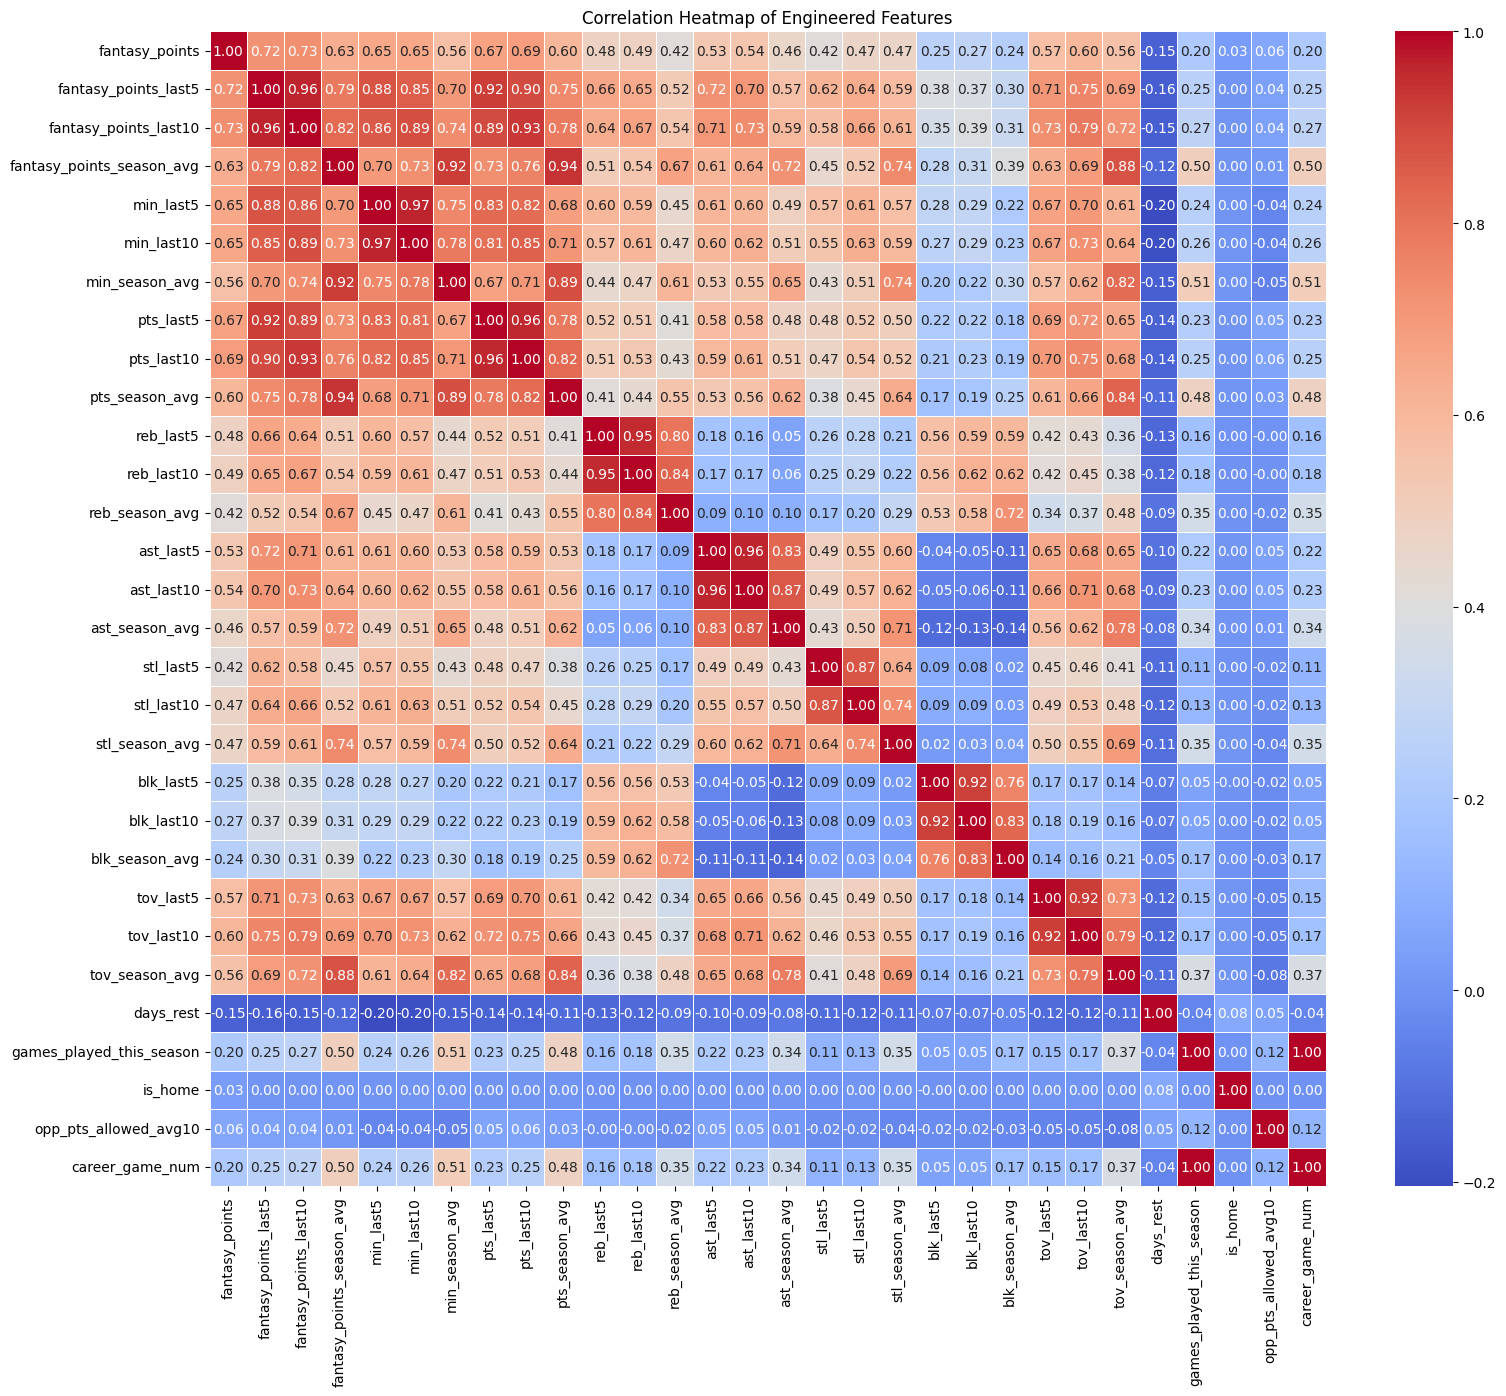

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify engineered features (using the logic from feature_summary)
engineered_cols = [c for c in features.columns if any(
    c.endswith(s) for s in ["_last5", "_last10", "_season_avg", "_avg10"]
) or c in ["days_rest", "is_home", "games_played_this_season", "career_game_num", "fantasy_points", "opp_pts_allowed_avg10"]]

# Filter for numerical columns within the engineered features for correlation calculation
numerical_engineered_features = features[engineered_cols].select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_engineered_features.corr()

# Plot the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Engineered Features')
plt.show()

## Visualizing Fantasy Points and Key Connections

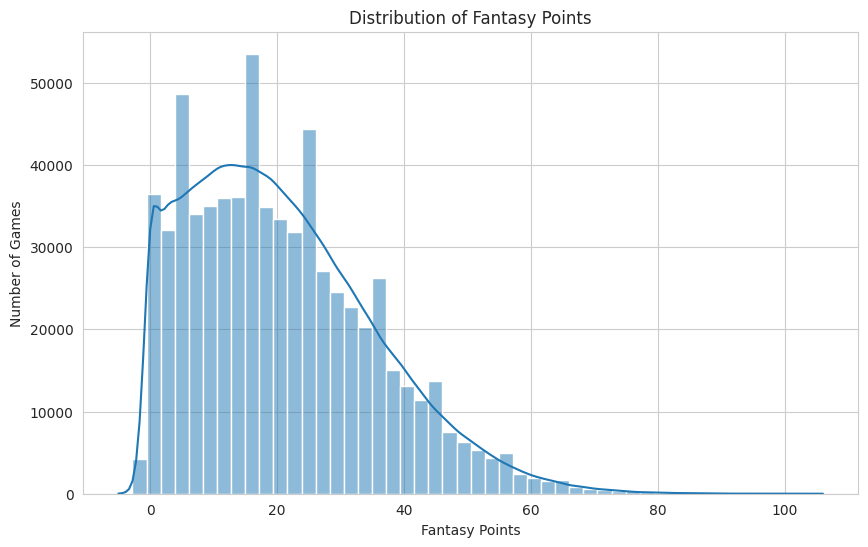

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# 1. Distribution of Fantasy Points
plt.figure(figsize=(10, 6))
sns.histplot(features['fantasy_points'], bins=50, kde=True)
plt.title('Distribution of Fantasy Points')
plt.xlabel('Fantasy Points')
plt.ylabel('Number of Games')
plt.show()

## Preparing Data for Model Training

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows with any NaN values that might have resulted from rolling features where history is insufficient
features_clean = features.dropna(subset=['fantasy_points'] + [col for col in features.columns if '_last' in col or '_season_avg' in col or 'opp_pts_allowed_avg10' in col])

# Define target and features
y = features_clean['fantasy_points']
X = features_clean[engineered_cols].drop(columns=['fantasy_points'])

# Drop non-numeric columns from X before scaling/training if any were missed
X = X.select_dtypes(include=np.number)

print(f"Shape of X after cleaning and selection: {X.shape}")
print(f"Shape of y after cleaning and selection: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of X after cleaning and selection: (671000, 29)
Shape of y after cleaning and selection: (671000,)
X_train shape: (536800, 29)
X_test shape: (134200, 29)
y_train shape: (536800,)
y_test shape: (134200,)


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-import config and the feature engineering functions
import config

# Re-define FP_WEIGHTS and WINDOWS (copied from original source for self-containment)
FP_WEIGHTS = {
    "PTS": 1,
    "REB": 1,
    "AST": 2,
    "BLK": 3,
    "STL": 3,
    "TOV": -1,
}
WINDOWS = [5, 10]

def compute_fantasy_points(df: pd.DataFrame) -> pd.Series:
    """Compute per-game fantasy points from raw box score stats."""
    fp = sum(df[col] * weight for col, weight in FP_WEIGHTS.items() if col in df.columns)
    return fp

def safe_minutes(min_series: pd.Series) -> pd.Series:
    """
    Convert MIN column to float. NBA API returns minutes as strings
    like '32:14' (minutes:seconds) or plain '32'. Handles both.
    """
    def parse_min(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip()
        if ":" in s:
            parts = s.split(":")
            return float(parts[0]) + float(parts[1]) / 60
        try:
            return float(s)
        except ValueError:
            return np.nan

    return min_series.apply(parse_min)

def _merge_opponent_context(
    player_df: pd.DataFrame,
    team_games: pd.DataFrame,
) -> pd.DataFrame:
    # Prepare team game data for merging
    tg = team_games.copy().rename(columns={
        'date': 'GAME_DATE',
        'game_id': 'GAME_ID',
        'home_team': 'HOME_TEAM_ABBREVIATION',
        'away_team': 'AWAY_TEAM_ABBREVIATION'
    })
    tg['GAME_DATE'] = pd.to_datetime(tg['GAME_DATE'])

    # Merge player_df with team_games to get home/away team for each player's game
    df_merged = pd.merge(
        player_df,
        tg[['GAME_ID', 'GAME_DATE', 'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'home_score', 'away_score']],
        on=['GAME_ID', 'GAME_DATE'],
        how='left'
    )

    # Determine is_home and opp_team_abbreviation
    df_merged['is_home'] = (
        df_merged['TEAM_ABBREVIATION'] == df_merged['HOME_TEAM_ABBREVIATION']
    ).astype(float)

    df_merged['opp_team'] = df_merged.apply(
        lambda row: row['AWAY_TEAM_ABBREVIATION'] if row['is_home'] == 1 else row['HOME_TEAM_ABBREVIATION'],
        axis=1
    )

    # Prepare data for rolling opponent stats (pts_allowed)
    team_def_home = pd.DataFrame({
        'GAME_DATE': tg['GAME_DATE'].values,
        'team_abbreviation': tg['HOME_TEAM_ABBREVIATION'].values,
        'pts_allowed': tg['away_score'].values
    })
    team_def_away = pd.DataFrame({
        'GAME_DATE': tg['GAME_DATE'].values,
        'team_abbreviation': tg['AWAY_TEAM_ABBREVIATION'].values,
        'pts_allowed': tg['home_score'].values
    })
    team_def = pd.concat([team_def_home, team_def_away], ignore_index=True)
    team_def = team_def.sort_values(['team_abbreviation', 'GAME_DATE']).reset_index(drop=True)

    # Compute rolling average of points allowed
    tgrp = team_def.groupby('team_abbreviation', sort=False)
    team_def['opp_pts_allowed_avg10'] = (
        tgrp['pts_allowed'].shift(1)
        .groupby(team_def['team_abbreviation'])
        .transform(lambda x: x.rolling(10, min_periods=1).mean())
    )

    # Merge rolling opponent stats back into player_df
    final_df = pd.merge(
        df_merged,
        team_def[['GAME_DATE', 'team_abbreviation', 'opp_pts_allowed_avg10']].rename(
            columns={'team_abbreviation': 'opp_team'}
        ),
        on=['GAME_DATE', 'opp_team'],
        how='left'
    )

    return final_df.drop(columns=['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'home_score', 'away_score'])

def build_rolling_features(
    player_logs: pd.DataFrame,
    team_games: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Build pre-game rolling features for every player-game row.

    Leakage prevention strategy:
        - Sort by date ascending before all groupby operations.
        - Use .shift(1) so each row only sees games BEFORE the current game.
        - Rolling windows operate on the shifted series.
        - No information from game N is used to predict game N.

    Args:
        player_logs:  Raw nba_player_game_logs.csv as a DataFrame.
        team_games:   Optional nba_historical_games.csv for opponent context.

    Returns:
        DataFrame with original columns plus engineered features.
        Rows where rolling windows have insufficient history are kept
        but will contain NaN — drop or impute downstream as needed.
    """
    df = player_logs.copy()

    # ── 1. Parse and sort ─────────────────────────────────────────────
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df["MIN"] = safe_minutes(df["MIN"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # ── 2. Compute per-game fantasy points ───────────────────────────────
    df["fantasy_points"] = compute_fantasy_points(df)

    # ── 3. Player-level rolling features ─────────────────────────
    grp = df.groupby("PLAYER_ID", sort=False)

    stat_cols = ["fantasy_points", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TOV"]

    for col in stat_cols:
        if col not in df.columns:
            continue

        shifted = grp[col].shift(1)  # exclude current game

        for window in WINDOWS:
            df[f"{col.lower()}_last{window}"] = (
                shifted
                .groupby(df["PLAYER_ID"])
                .transform(lambda x: x.rolling(window, min_periods=1).mean())
            )

        df[f"{col.lower()}_season_avg"] = (
            shifted
            .groupby(df["PLAYER_ID"])
            .transform(lambda x: x.expanding(min_periods=1).mean())
        )

    # ── 4. Rest / schedule context ────────────────────────────
    df["days_rest"] = (
        grp["GAME_DATE"]
        .diff()
        .dt.days
        .clip(upper=7)
    )

    # Games played so far this season (proxy for fatigue / rotation depth)
    df["games_played_this_season"] = grp.cumcount()

    # ── 5. Home / away flag and Opponent defensive context (from team game logs) ───────────────────────────────
    if team_games is not None:
        df = _merge_opponent_context(df, team_games)
    else:
        # If team_games are not provided, these columns will be NaN
        df['is_home'] = np.nan
        df['opp_team'] = np.nan
        df['opp_pts_allowed_avg10'] = np.nan

    # ── 6. Games since player's first appearance (career age proxy) ─────────────────────
    df["career_game_num"] = grp.cumcount()

    return df

# Load data again
print("Loading data for feature engineering...")
players = pd.read_csv(config.PLAYER_GAME_LOGS_CSV)
teams = pd.read_csv(config.HISTORICAL_GAMES_CSV)

print(f"  Player rows: {len(players):,}")
print(f"  Team games:  {len(teams):,}")

print("\nBuilding rolling features...")
features = build_rolling_features(players, teams)

print(f"\nResulting shape: {features.shape}")

# Define engineered_cols here as well for self-containment
engineered_cols = [c for c in features.columns if any(
    c.endswith(s) for s in ["_last5", "_last10", "_season_avg", "_avg10"]
) or c in ["days_rest", "is_home", "games_played_this_season", "career_game_num", "fantasy_points", "opp_pts_allowed_avg10"]]


# Drop rows with any NaN values that might have resulted from rolling features where history is insufficient
features_clean = features.dropna(subset=['fantasy_points'] + [col for col in features.columns if '_last' in col or '_season_avg' in col or 'opp_pts_allowed_avg10' in col])

# Define target and features
y = features_clean['fantasy_points']
X = features_clean[engineered_cols].drop(columns=['fantasy_points'])

# Drop non-numeric columns from X before scaling/training if any were missed
X = X.select_dtypes(include=np.number)

print(f"Shape of X after cleaning and selection: {X.shape}")
print(f"Shape of y after cleaning and selection: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Loading data for feature engineering...
  Player rows: 673,733
  Team games:  32,444

Building rolling features...

Resulting shape: (673733, 55)
Shape of X after cleaning and selection: (671000, 29)
Shape of y after cleaning and selection: (671000,)
X_train shape: (536800, 29)
X_test shape: (134200, 29)
y_train shape: (536800,)
y_test shape: (134200,)


## Ridge and Lasso Regression Tuning

In [17]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Create pipelines for Ridge and Lasso regression
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

# Define parameter grids for tuning
ridge_param_grid = {
    'ridge__alpha': np.logspace(-3, 3, 7) # Example: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

lasso_param_grid = {
    'lasso__alpha': np.logspace(-4, 0, 5) # Example: [0.0001, 0.001, 0.01, 0.1, 1]
}

# Perform GridSearchCV for Ridge Regression
print("Tuning Ridge Regression...")
ridge_grid_search = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
ridge_grid_search.fit(X_train, y_train)

print("\nBest parameters for Ridge Regression:", ridge_grid_search.best_params_)
print("Best cross-validation MSE for Ridge Regression:", -ridge_grid_search.best_score_)

# Perform GridSearchCV for Lasso Regression
print("\nTuning Lasso Regression...")
lasso_grid_search = GridSearchCV(lasso_pipeline, lasso_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
lasso_grid_search.fit(X_train, y_train)

print("\nBest parameters for Lasso Regression:", lasso_grid_search.best_params_)
print("Best cross-validation MSE for Lasso Regression:", -lasso_grid_search.best_score_)

# Store best models
best_ridge_model = ridge_grid_search.best_estimator_
best_lasso_model = lasso_grid_search.best_estimator_

print("\nRidge and Lasso regression tuning complete. Best models are stored in `best_ridge_model` and `best_lasso_model`.")

Tuning Ridge Regression...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best parameters for Ridge Regression: {'ridge__alpha': 10.0}
Best cross-validation MSE for Ridge Regression: 95.49743492877913

Tuning Lasso Regression...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters for Lasso Regression: {'lasso__alpha': 0.0001}
Best cross-validation MSE for Lasso Regression: 95.49744338223084

Ridge and Lasso regression tuning complete. Best models are stored in `best_ridge_model` and `best_lasso_model`.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.735e+06, tolerance: 1.140e+04
  model = cd_fast.enet_coordinate_descent(


In [18]:
import numpy as np

ridge_mse = -ridge_grid_search.best_score_
lasso_mse = -lasso_grid_search.best_score_

ridge_rmse = np.sqrt(ridge_mse)
lasso_rmse = np.sqrt(lasso_mse)

print(f"Ridge Regression RMSE: {ridge_rmse:.2f} fantasy points")
print(f"Lasso Regression RMSE: {lasso_rmse:.2f} fantasy points")

Ridge Regression RMSE: 9.77 fantasy points
Lasso Regression RMSE: 9.77 fantasy points


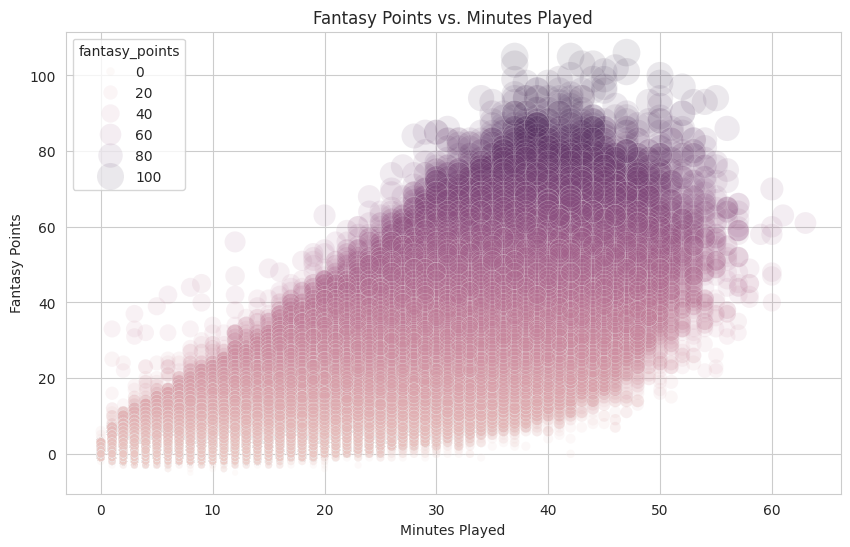

In [19]:
# 2. Fantasy Points vs. Minutes Played
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MIN', y='fantasy_points', data=features, alpha=0.1, hue='fantasy_points', size='fantasy_points', sizes=(20, 400), legend='brief')
plt.title('Fantasy Points vs. Minutes Played')
plt.xlabel('Minutes Played')
plt.ylabel('Fantasy Points')
plt.show()

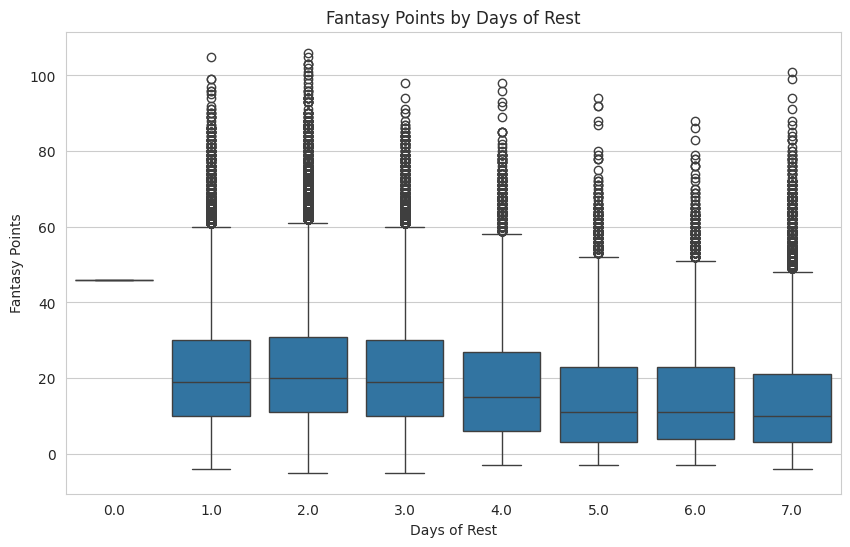

In [20]:
# 3. Fantasy Points vs. Days Rest
plt.figure(figsize=(10, 6))
sns.boxplot(x='days_rest', y='fantasy_points', data=features)
plt.title('Fantasy Points by Days of Rest')
plt.xlabel('Days of Rest')
plt.ylabel('Fantasy Points')
plt.show()

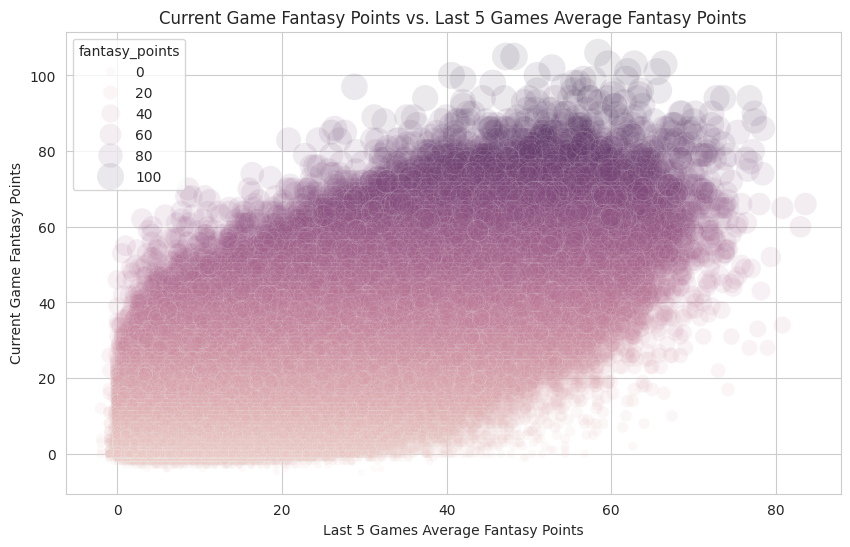

In [21]:
# 4. Fantasy Points vs. Last 5 Games Rolling Average Fantasy Points
plt.figure(figsize=(10, 6))
sns.scatterplot(x='fantasy_points_last5', y='fantasy_points', data=features, alpha=0.1, hue='fantasy_points', size='fantasy_points', sizes=(20, 400), legend='brief')
plt.title('Current Game Fantasy Points vs. Last 5 Games Average Fantasy Points')
plt.xlabel('Last 5 Games Average Fantasy Points')
plt.ylabel('Current Game Fantasy Points')
plt.show()

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge


# ── Column lists ──────────────────────────────────────────────────────────────

TARGET = "fantasy_points"

# Drop anything that would leak the current game's outcome or is non-numeric
EXCLUDE = {
    TARGET,
    # Identifiers
    "PLAYER_ID", "PLAYER_NAME", "TEAM_ID", "TEAM_ABBREVIATION",
    "GAME_ID", "GAME_DATE", "SEASON_ID", "MATCHUP", "opp_team",
    "career_game_num",
    # Raw same-game box score stats (these ARE the target — pure leakage)
    "PTS", "REB", "AST", "BLK", "STL", "TOV",
    "FGM", "FGA", "FTM", "FTA", "FG3M", "FG3A",
    "FG_PCT", "FT_PCT", "FG3_PCT", "PLUS_MINUS", "MIN","is_home"
}


def get_feature_cols(df: pd.DataFrame) -> list[str]:
    """
    Return the list of usable predictor columns: numeric, non-excluded,
    and present in the dataframe.
    """
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in numeric if c not in EXCLUDE]


# ── Strategy 1: Hard date split ───────────────────────────────────────────────

def hard_split(
    df: pd.DataFrame,
    val_start: str = "2023-10-01",
    test_start: str = "2024-10-01",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split by fixed calendar dates.

    Train  → seasons 2000–23  (the bulk of learning)
    Val    → season  2023–24  (tune hyperparameters here)
    Test   → season  2024–25  (touch ONCE at the very end)
    """
    df = df.copy()
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])

    train = df[df["GAME_DATE"] < val_start]
    val   = df[(df["GAME_DATE"] >= val_start) & (df["GAME_DATE"] < test_start)]
    test  = df[df["GAME_DATE"] >= test_start]

    print("Hard date split")
    print(f"  Train : {len(train):>7,} rows  "
          f"({train['GAME_DATE'].min().date()} -> {train['GAME_DATE'].max().date()})")
    print(f"  Val   : {len(val):>7,} rows  "
          f"({val['GAME_DATE'].min().date()} -> {val['GAME_DATE'].max().date()})")
    print(f"  Test  : {len(test):>7,} rows  "
          f"({test['GAME_DATE'].min().date()} -> {test['GAME_DATE'].max().date()})")

    return train, val, test


def split_xy(
    df: pd.DataFrame,
    feature_cols: list[str],
    min_games: int = 5,
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Extract X and y from a split.

    Leakage-safe NaN handling:
      - Drop rows where the target is NaN (can't train on these).
      - Drop rows where career_game_num < min_games so rolling windows
        cover enough history to be meaningful.
      - Impute any remaining NaN features with the column median.
        This is far safer than .dropna() on all feature cols, which
        silently empties the DataFrame when rolling cols are all NaN.

    min_games=5 ensures fantasy_points_last5 is always a real 5-game
    average, not a 1- or 2-game noise estimate.
    """
    subset = df.copy()

    # Must have a valid target
    subset = subset[subset[TARGET].notna()]

    # Drop early-career rows where rolling features are too sparse
    if "career_game_num" in subset.columns:
        before = len(subset)
        subset = subset[subset["career_game_num"] >= min_games]
        dropped = before - len(subset)
        if dropped:
            print(f"  split_xy: dropped {dropped:,} rows with < {min_games} games played")

    # Only keep columns we need
    cols_needed = [c for c in feature_cols if c in subset.columns]
    subset = subset[cols_needed + [TARGET]].copy()

    # Impute remaining NaNs with column median rather than dropping whole rows
    nan_counts = subset[cols_needed].isna().sum()
    if nan_counts.any():
        medians = subset[cols_needed].median(numeric_only=True)
        subset[cols_needed] = subset[cols_needed].fillna(medians)

    print(f"  split_xy: {len(subset):,} usable rows, {len(cols_needed)} features")

    return subset[cols_needed], subset[TARGET]


# ── Strategy 2: Walk-forward TimeSeriesSplit CV ───────────────────────────────

def make_tscv(n_splits: int = 5) -> TimeSeriesSplit:
    """
    Build a TimeSeriesSplit for use inside GridSearchCV or cross_val_score.

    Each fold expands the training window and validates on the immediately
    following chunk — always strictly forward in time.

    Visual (n_splits=3):
        Fold 1  Train [=======]          Val [===]
        Fold 2  Train [===========]      Val [===]
        Fold 3  Train [===============]  Val [===]

    NOTE: TimeSeriesSplit uses row ORDER, not dates. X_train must be
    sorted by date before being passed in (build_rolling_features
    guarantees this).
    """
    return TimeSeriesSplit(n_splits=n_splits)


def cv_on_train(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    model,
    n_splits: int = 5,
    scoring: str = "neg_root_mean_squared_error",
) -> dict:
    """
    Run walk-forward cross-validation on the training window only.

    Returns dict with per-fold RMSE scores and mean +/- std.
    """
    tscv = make_tscv(n_splits)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
    )

    rmse_scores = -scores if "neg_" in scoring else scores

    result = {
        "fold_scores": rmse_scores,
        "mean": rmse_scores.mean(),
        "std":  rmse_scores.std(),
    }

    print(f"\nWalk-forward CV  (n_splits={n_splits}, scoring={scoring})")
    for i, s in enumerate(rmse_scores, 1):
        print(f"  Fold {i}: {s:.3f}")
    print(f"  Mean +/- Std: {result['mean']:.3f} +/- {result['std']:.3f}")

    return result


# ── Example: full workflow ────────────────────────────────────────────────────

if __name__ == "__main__":
    from config import PLAYER_GAME_LOGS_CSV, HISTORICAL_GAMES_CSV
    # build_rolling_features is already defined in the global scope from cell yO0C16xHHlbL
    # from rolling_features import build_rolling_features

    print("Loading data...")
    players = pd.read_csv(PLAYER_GAME_LOGS_CSV)
    teams   = pd.read_csv(HISTORICAL_GAMES_CSV)
    df = build_rolling_features(players, teams)

    print(f"\nFull dataset: {df.shape}")
    print(f"Date range:   {df['GAME_DATE'].min()} -> {df['GAME_DATE'].max()}")

    # Hard split
    train_df, val_df, test_df = hard_split(df)

    feature_cols = get_feature_cols(df)
    print(f"\nFeatures available ({len(feature_cols)}): {feature_cols}")

    print("\nBuilding X/y splits...")
    X_train, y_train = split_xy(train_df, feature_cols)
    X_val,   y_val   = split_xy(val_df,   feature_cols)
    X_test,  y_test  = split_xy(test_df,  feature_cols)  # hold-out -- touch last!

    print(f"\nX_train: {X_train.shape}")
    print(f"X_val  : {X_val.shape}")
    print(f"X_test : {X_test.shape}  <- evaluate once at the very end")

    # Baseline: Ridge with walk-forward CV
    baseline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # handles any remaining NaNs
        ("scaler",  StandardScaler()),
        ("model",   Ridge(alpha=1.0)),
    ])

    cv_on_train(X_train, y_train, baseline, n_splits=5)

    # Val-set score
    baseline.fit(X_train, y_train)
    val_preds = baseline.predict(X_val)
    val_rmse  = np.sqrt(((val_preds - y_val) ** 2).mean())
    print(f"\nVal RMSE (Ridge baseline): {val_rmse:.3f} FP")

    # Naive baseline -- predict each player's season-to-date average
    # Your model must beat this or something is wrong upstream
    if "fantasy_points_season_avg" in X_val.columns:
        naive_preds = X_val["fantasy_points_season_avg"]
        valid_idx   = naive_preds.notna() & y_val.notna()
        naive_rmse  = np.sqrt(((naive_preds[valid_idx] - y_val[valid_idx]) ** 2).mean())
        print(f"Val RMSE (naive season avg): {naive_rmse:.3f} FP  <- must beat this")

Loading data...

Full dataset: (673733, 55)
Date range:   1999-11-02 00:00:00 -> 2026-04-12 00:00:00
Hard date split
  Train : 594,375 rows  (1999-11-02 -> 2023-04-09)
  Val   :  26,401 rows  (2023-10-24 -> 2024-04-14)
  Test  :  52,957 rows  (2024-10-22 -> 2026-04-12)

Features available (27): ['fantasy_points_last5', 'fantasy_points_last10', 'fantasy_points_season_avg', 'min_last5', 'min_last10', 'min_season_avg', 'pts_last5', 'pts_last10', 'pts_season_avg', 'reb_last5', 'reb_last10', 'reb_season_avg', 'ast_last5', 'ast_last10', 'ast_season_avg', 'stl_last5', 'stl_last10', 'stl_season_avg', 'blk_last5', 'blk_last10', 'blk_season_avg', 'tov_last5', 'tov_last10', 'tov_season_avg', 'days_rest', 'games_played_this_season', 'opp_pts_allowed_avg10']

Building X/y splits...
  split_xy: dropped 11,338 rows with < 5 games played
  split_xy: 583,037 usable rows, 27 features
  split_xy: dropped 489 rows with < 5 games played
  split_xy: 25,912 usable rows, 27 features
  split_xy: dropped 1,018 

In [35]:
print(f"Initial dataset size: {len(df):,} rows")
covid_season = 22020 # Corrected season ID for 2019-2020 (COVID season)
df = df[df['SEASON_ID'] != covid_season].copy()
print(f"Dataset size after removing COVID season ({covid_season}): {len(df):,} rows")
print(f"Updated date range: {df['GAME_DATE'].min()} -> {df['GAME_DATE'].max()}")

Initial dataset size: 673,733 rows
Dataset size after removing COVID season (22020): 650,679 rows
Updated date range: 1999-11-02 00:00:00 -> 2026-04-12 00:00:00


## LightGBM Tuning (Faster Alternative)

Given the computational cost of Random Forest, let's explore LightGBM, a gradient boosting framework that uses tree-based learning algorithms. It's designed to be distributed and efficient, often training much faster than XGBoost and Random Forest, while maintaining high accuracy. We'll tune a few key parameters to find an optimal balance of speed and performance.

In [23]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline for LightGBM regression
lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', lgb.LGBMRegressor(random_state=42))
])

# Define parameter grids for tuning
# Keep it small for initial testing due to computational cost
lgbm_param_grid = {
    'lgbm__n_estimators': [100, 200], # Number of boosting rounds
    'lgbm__learning_rate': [0.05, 0.1], # Step size shrinkage
    'lgbm__num_leaves': [31, 63] # Max tree leaves for base learners
}

# Perform GridSearchCV for LightGBM Regression
print("Tuning LightGBM Regression...")
lgbm_grid_search = GridSearchCV(lgbm_pipeline, lgbm_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
lgbm_grid_search.fit(X_train, y_train)

print("\nBest parameters for LightGBM Regression:", lgbm_grid_search.best_params_)
print("Best cross-validation MSE for LightGBM Regression:", -lgbm_grid_search.best_score_)

# Calculate RMSE
lgbm_mse = -lgbm_grid_search.best_score_
lgbm_rmse = np.sqrt(lgbm_mse)

print(f"\nLightGBM Regression RMSE: {lgbm_rmse:.2f} fantasy points")

# Store best model
best_lgbm_model = lgbm_grid_search.best_estimator_


Tuning LightGBM Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5080
[LightGBM] [Info] Number of data points in the train set: 583037, number of used features: 27
[LightGBM] [Info] Start training from score 20.781871

Best parameters for LightGBM Regression: {'lgbm__learning_rate': 0.05, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 63}
Best cross-validation MSE for LightGBM Regression: 95.15408637864113

LightGBM Regression RMSE: 9.75 fantasy points


## Neural Network Tuning

Let's try a simple Artificial Neural Network (ANN) using Keras. Neural networks can capture non-linear relationships in the data that simpler models might miss. We will build a sequential model with a few dense layers and evaluate its performance. Given the computational cost of tuning neural networks, we'll start with a reasonable architecture and evaluate its performance first.

In [24]:
!pip install scikeras

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [25]:
!pip install scikit-learn==1.3.2

  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.8.0
    Uninstalling scikit-learn-1.8.0:
      Successfully uninstalled scikit-learn-1.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikeras 0.13.0 requires scikit-learn>=1.4.2, but you have scikit-learn 1.3.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
esda 2.9.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have nump

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define the neural network model within a function for use in a KerasRegressor
def create_nn_model(input_dim, learning_rate=0.001, hidden_layers=1, neurons_per_layer=64):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    # Add hidden layers
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
        model.add(layers.Dropout(0.2)) # Add dropout for regularization

    # Output layer
    model.add(layers.Dense(1, activation='linear')) # Regression task

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Build a pipeline including the StandardScaler and the Keras model
# We'll wrap the Keras model in a scikit-learn compatible wrapper
# However, for simplicity here, we'll just preprocess X_train and X_val directly and then train

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Determine input dimension
input_dim = X_train_scaled.shape[1]

# Create and compile the model
nn_model = create_nn_model(input_dim=input_dim, learning_rate=0.001, hidden_layers=2, neurons_per_layer=128)

# Train the model
print("\nTraining Neural Network...")
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=10, # Start with a few epochs, can increase if needed
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

# Evaluate the model on the validation set
val_loss = nn_model.evaluate(X_val_scaled, y_val, verbose=0)
nn_rmse = np.sqrt(val_loss)

print(f"\nNeural Network Validation RMSE: {nn_rmse:.2f} fantasy points")



Training Neural Network...
Epoch 1/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 101.2863 - val_loss: 103.0029
Epoch 2/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 98.6486 - val_loss: 102.9507
Epoch 3/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 98.2006 - val_loss: 101.9137
Epoch 4/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 97.8205 - val_loss: 103.4718
Epoch 5/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 97.5955 - val_loss: 103.3249
Epoch 6/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 97.3013 - val_loss: 102.6288
Epoch 7/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 97.1666 - val_loss: 102.9406
Epoch 8/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 96.9928 - val_loss: 103.1379
Epoch 9/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 96.8957 - val_loss: 101.7234
Epoch 10/10
18220/18220 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 96.6995 - val_loss: 103.3161

Neural Network Validation RMS

## Hypertuning the Neural Network with GridSearchCV

To systematically find better hyperparameters for our Neural Network, we'll use `GridSearchCV` with `KerasRegressor` from `scikeras.wrappers`. This allows us to treat our Keras model like a scikit-learn estimator and tune parameters such as the learning rate, number of hidden layers, and neurons per layer.

We'll define a parameter grid, keeping the number of options somewhat limited to manage the computational cost. We'll also use fewer `epochs` during the grid search than for final training, as the goal is to find good parameter *combinations* quickly, rather than fully train each candidate model.

In [27]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

# Define the neural network model within a function for use in a KerasRegressor
def create_nn_model(input_dim, learning_rate=0.001, hidden_layers=1, neurons_per_layer=64):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    # Add hidden layers
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
        model.add(layers.Dropout(0.2)) # Add dropout for regularization

    # Output layer
    model.add(layers.Dense(1, activation='linear')) # Regression task

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Scale the data first, ensuring X_train and y_train are available from previous cells
# (Assuming X_train and y_train are already defined globally from cell 1f5c05c9)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
y_train_scaled = y_train # Target 'y' does not need scaling for MSE loss

# Create a KerasRegressor wrapper for our model
# We pass input_dim as an argument to build_fn since it's needed during model creation
keras_regressor = KerasRegressor(
    model=create_nn_model,
    input_dim=X_train_scaled.shape[1],
    verbose=0, # Suppress Keras output during grid search
    # Note: epochs and batch_size will be passed to model.fit internally.
    # For grid search, it's good to keep epochs relatively low.
    epochs=3 # Reduced epochs for faster grid search
)

# Define the parameter grid for tuning
nn_param_grid = {
    'model__learning_rate': [0.001],
    'model__hidden_layers': [1],
    'model__neurons_per_layer': [64, 128],
    'batch_size': [64]
}

# Set up GridSearchCV for the Neural Network
print("\nHypertuning Neural Network with GridSearchCV...")

# Ensure X_train_scaled is dense if it was sparse after some operation
if isinstance(X_train_scaled, (np.ndarray, pd.DataFrame)) and hasattr(X_train_scaled, 'toarray'):
    X_train_scaled = X_train_scaled.toarray()

nn_grid_search = GridSearchCV(
    estimator=keras_regressor,
    param_grid=nn_param_grid,
    cv=3, # Using 3-fold cross-validation for speed
    scoring='neg_mean_squared_error',
    n_jobs=-1, # Use all available cores
    verbose=1
)

nn_grid_search.fit(X_train_scaled, y_train_scaled)

print("\nBest parameters for Neural Network:", nn_grid_search.best_params_)
print("Best cross-validation MSE for Neural Network:", -nn_grid_search.best_score_)

# Calculate RMSE for the best NN model
best_nn_mse = -nn_grid_search.best_score_
best_nn_rmse = np.sqrt(best_nn_mse)

print(f"\nNeural Network Best RMSE: {best_nn_rmse:.2f} fantasy points")

# Store the best model
best_nn_model = nn_grid_search.best_estimator_


Hypertuning Neural Network with GridSearchCV...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Best parameters for Neural Network: {'batch_size': 64, 'model__hidden_layers': 1, 'model__learning_rate': 0.001, 'model__neurons_per_layer': 64}
Best cross-validation MSE for Neural Network: 95.24746202414839

Neural Network Best RMSE: 9.76 fantasy points


In [29]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming lgbm_grid_search is available from a previous run
# If not, you might need to re-run the LightGBM tuning cell or define lgbm_rmse here
# For this comparison, we'll assume lgbm_rmse is already defined.

# Create a pipeline for XGBoost regression
xgboost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(random_state=42, tree_method='hist')) # 'hist' for faster training
])

# Define parameter grids for tuning (keeping it small for initial test)
xgboost_param_grid = {
    'xgb__n_estimators': [100, 200], # Number of boosting rounds
    'xgb__learning_rate': [0.05, 0.1], # Step size shrinkage
    'xgb__max_depth': [6, 8] # Maximum depth of a tree
}

# Perform GridSearchCV for XGBoost Regression
print("\nTuning XGBoost Regression...")
xgb_grid_search = GridSearchCV(xgboost_pipeline, xgboost_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
xgb_grid_search.fit(X_train, y_train)

print("\nBest parameters for XGBoost Regression:", xgb_grid_search.best_params_)
print("Best cross-validation MSE for XGBoost Regression:", -xgb_grid_search.best_score_)

# Calculate RMSE
xgb_mse = -xgb_grid_search.best_score_
xgb_rmse = np.sqrt(xgb_mse)

print(f"\nXGBoost Regression RMSE: {xgb_rmse:.2f} fantasy points")

# Store best model
best_xgboost_model = xgb_grid_search.best_estimator_

# Compare with LightGBM (assuming lgbm_rmse is available)
print(f"\nComparison:\nLightGBM RMSE: {np.sqrt(-lgbm_grid_search.best_score_):.2f} FP\nXGBoost RMSE: {xgb_rmse:.2f} FP")


Tuning XGBoost Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters for XGBoost Regression: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 6, 'xgb__n_estimators': 100}
Best cross-validation MSE for XGBoost Regression: 95.1620387777373

XGBoost Regression RMSE: 9.76 fantasy points

Comparison:
LightGBM RMSE: 9.75 FP
XGBoost RMSE: 9.76 FP


In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
import lightgbm as lgb
import xgboost as xgb
from scikeras.wrappers import KerasRegressor
from tensorflow import keras
from tensorflow.keras import layers


# Define the neural network model within a function for use in a KerasRegressor
# (re-defining for self-containment in this cell)
def create_nn_model(input_dim, learning_rate=0.001, hidden_layers=1, neurons_per_layer=64):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation='linear'))
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model


print("--- Evaluating models on a subset of data (last 10 years, excluding Covid-2020) ---")

# 1. Define the subset criteria and create the subset of data
# `df` is already available from cell JWyPqIOFUMJn

current_max_season_in_df = df['SEASON_ID'].max()
start_season_subset = current_max_season_in_df - 10 # 10 years back from current max season
covid_season = 2020 # The 2019-2020 season is represented as season = 2020 in the dataframe

print(f"Original dataset date range: {df['GAME_DATE'].min().date()} to {df['GAME_DATE'].max().date()}")
print(f"Filtering for seasons from {start_season_subset} to {current_max_season_in_df}, excluding {covid_season}...")

df_subset = df[
    (df['SEASON_ID'] >= start_season_subset) &
    (df['SEASON_ID'] <= current_max_season_in_df) &
    (df['SEASON_ID'] != covid_season)
].copy()

print(f"\nSubset dataset shape: {df_subset.shape}")
print(f"Subset date range: {df_subset['GAME_DATE'].min().date()} to {df_subset['GAME_DATE'].max().date()}")

# 2. Split the subset data using the hard_split function
# `hard_split` and `split_xy` functions are available from cell JWyPqIOFUMJn
# The val_start and test_start dates are chosen to be within the recent seasons of the subset
train_df_subset, val_df_subset, test_df_subset = hard_split(df_subset, val_start="2023-10-01", test_start="2024-10-01")

# 3. Extract X and y for the subset
feature_cols_subset = get_feature_cols(df_subset)

print("\nBuilding X/y splits for subset...")
X_train_subset, y_train_subset = split_xy(train_df_subset, feature_cols_subset)
X_val_subset, y_val_subset = split_xy(val_df_subset, feature_cols_subset)
# X_test_subset, y_test_subset = split_xy(test_df_subset, feature_cols_subset) # Not using test set for this comparison

print(f"\nX_train_subset: {X_train_subset.shape}")
print(f"X_val_subset: {X_val_subset.shape}")

# Initialize a dictionary to store RMSE results for comparison
subset_rmse_results = {}

# --- Retrain and Evaluate Ridge Model on Subset ---
print("\nEvaluating Ridge Regression on subset...")
# Use best alpha from previous tuning (best_ridge_model from cell c9f2f7ee)
ridge_pipeline_subset = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_ridge_model.named_steps['ridge'].alpha))
])
ridge_pipeline_subset.fit(X_train_subset, y_train_subset)
val_preds_ridge_subset = ridge_pipeline_subset.predict(X_val_subset)
ridge_rmse_subset = np.sqrt(((val_preds_ridge_subset - y_val_subset) ** 2).mean())
subset_rmse_results['Ridge'] = ridge_rmse_subset
print(f"Ridge Regression RMSE on subset: {ridge_rmse_subset:.2f} FP")

# --- Retrain and Evaluate Lasso Model on Subset ---
print("\nEvaluating Lasso Regression on subset...")
# Use best alpha from previous tuning (best_lasso_model from cell c9f2f7ee)
lasso_pipeline_subset = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=best_lasso_model.named_steps['lasso'].alpha, max_iter=2000)) # Increase max_iter for convergence
])
lasso_pipeline_subset.fit(X_train_subset, y_train_subset)
val_preds_lasso_subset = lasso_pipeline_subset.predict(X_val_subset)
lasso_rmse_subset = np.sqrt(((val_preds_lasso_subset - y_val_subset) ** 2).mean())
subset_rmse_results['Lasso'] = lasso_rmse_subset
print(f"Lasso Regression RMSE on subset: {lasso_rmse_subset:.2f} FP")

# --- Retrain and Evaluate LightGBM Model on Subset ---
print("\nEvaluating LightGBM Regression on subset...")
# Use best parameters from previous tuning (best_lgbm_model from cell 3221fdba)
lgbm_pipeline_subset = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', lgb.LGBMRegressor(
        random_state=42,
        n_estimators=best_lgbm_model.named_steps['lgbm'].n_estimators,
        learning_rate=best_lgbm_model.named_steps['lgbm'].learning_rate,
        num_leaves=best_lgbm_model.named_steps['lgbm'].num_leaves
    ))
])
lgbm_pipeline_subset.fit(X_train_subset, y_train_subset)
val_preds_lgbm_subset = lgbm_pipeline_subset.predict(X_val_subset)
lgbm_rmse_subset = np.sqrt(((val_preds_lgbm_subset - y_val_subset) ** 2).mean())
subset_rmse_results['LightGBM'] = lgbm_rmse_subset
print(f"LightGBM Regression RMSE on subset: {lgbm_rmse_subset:.2f} FP")

# --- Retrain and Evaluate XGBoost Model on Subset ---
print("\nEvaluating XGBoost Regression on subset...")
# Use best parameters from previous tuning (best_xgboost_model from cell 16b91a75)
xgboost_pipeline_subset = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(
        random_state=42,
        tree_method='hist',
        n_estimators=best_xgboost_model.named_steps['xgb'].n_estimators,
        learning_rate=best_xgboost_model.named_steps['xgb'].learning_rate,
        max_depth=best_xgboost_model.named_steps['xgb'].max_depth
    ))
])
xgboost_pipeline_subset.fit(X_train_subset, y_train_subset)
val_preds_xgboost_subset = xgboost_pipeline_subset.predict(X_val_subset)
xgboost_rmse_subset = np.sqrt(((val_preds_xgboost_subset - y_val_subset) ** 2).mean())
subset_rmse_results['XGBoost'] = xgboost_rmse_subset
print(f"XGBoost Regression RMSE on subset: {xgboost_rmse_subset:.2f} FP")

# --- Retrain and Evaluate Neural Network Model on Subset ---
print("\nEvaluating Neural Network on subset...")
# Scale the data for NN separately
scaler_nn_subset = StandardScaler()
X_train_nn_scaled_subset = scaler_nn_subset.fit_transform(X_train_subset)
X_val_nn_scaled_subset = scaler_nn_subset.transform(X_val_subset)

# Get best NN params from previous grid search (best_nn_model from cell 8d8c4fed)
best_nn_params = best_nn_model.get_params()
nn_model_subset = create_nn_model(
    input_dim=X_train_nn_scaled_subset.shape[1],
    learning_rate=best_nn_params['model__learning_rate'],
    hidden_layers=best_nn_params['model__hidden_layers'],
    neurons_per_layer=best_nn_params['model__neurons_per_layer']
)
nn_model_subset.fit(
    X_train_nn_scaled_subset, y_train_subset,
    epochs=10, # Use more epochs for evaluation than during grid search
    batch_size=best_nn_params['batch_size'],
    validation_data=(X_val_nn_scaled_subset, y_val_subset),
    verbose=0 # Suppress verbose output during training in this cell
)
val_loss_nn_subset = nn_model_subset.evaluate(X_val_nn_scaled_subset, y_val_subset, verbose=0)
nn_rmse_subset = np.sqrt(val_loss_nn_subset)
subset_rmse_results['Neural Network'] = nn_rmse_subset
print(f"Neural Network RMSE on subset: {nn_rmse_subset:.2f} FP")

# --- Naive Baseline on Subset ---
# `naive_preds` and `naive_rmse` (full dataset) are available from cell JWyPqIOFUMJn
if "fantasy_points_season_avg" in X_val_subset.columns:
    naive_preds_subset = X_val_subset["fantasy_points_season_avg"]
    valid_idx_subset = naive_preds_subset.notna() & y_val_subset.notna()
    naive_rmse_subset = np.sqrt(((naive_preds_subset[valid_idx_subset] - y_val_subset[valid_idx_subset]) ** 2).mean())
    subset_rmse_results['Naive Baseline'] = naive_rmse_subset
    print(f"Naive Baseline RMSE on subset: {naive_rmse_subset:.2f} FP")


# 4. Compare results (existing RMSE values for full dataset are taken from kernel state)
print("\n--- Comparison of Models (Full Dataset vs. Subset) ---")
print("Model                | Full Dataset RMSE | Subset RMSE")
print("---------------------|-------------------|-------------")
print(f"Ridge Regression     | {ridge_rmse:.2f} FP        | {subset_rmse_results['Ridge']:.2f} FP")
print(f"Lasso Regression     | {lasso_rmse:.2f} FP        | {subset_rmse_results['Lasso']:.2f} FP")
print(f"LightGBM             | {lgbm_rmse:.2f} FP        | {subset_rmse_results['LightGBM']:.2f} FP")
print(f"XGBoost              | {xgb_rmse:.2f} FP         | {subset_rmse_results['XGBoost']:.2f} FP")
print(f"Neural Network       | {nn_rmse:.2f} FP         | {subset_rmse_results['Neural Network']:.2f} FP")
print(f"Naive Baseline       | {naive_rmse:.2f} FP       | {subset_rmse_results['Naive Baseline']:.2f} FP")


--- Evaluating models on a subset of data (last 10 years, excluding Covid-2020) ---
Original dataset date range: 1999-11-02 to 2026-04-12
Filtering for seasons from 22015 to 22025, excluding 2020...

Subset dataset shape: (281164, 55)
Subset date range: 2015-10-27 to 2026-04-12
Hard date split
  Train : 201,806 rows  (2015-10-27 -> 2023-04-09)
  Val   :  26,401 rows  (2023-10-24 -> 2024-04-14)
  Test  :  52,957 rows  (2024-10-22 -> 2026-04-12)

Building X/y splits for subset...
  split_xy: dropped 3,848 rows with < 5 games played
  split_xy: 197,958 usable rows, 27 features
  split_xy: dropped 489 rows with < 5 games played
  split_xy: 25,912 usable rows, 27 features

X_train_subset: (197958, 27)
X_val_subset: (25912, 27)

Evaluating Ridge Regression on subset...
Ridge Regression RMSE on subset: 10.12 FP

Evaluating Lasso Regression on subset...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.389e+06, tolerance: 4.232e+03
  model = cd_fast.enet_coordinate_descent(


Lasso Regression RMSE on subset: 10.12 FP

Evaluating LightGBM Regression on subset...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 197958, number of used features: 27
[LightGBM] [Info] Start training from score 21.490740
LightGBM Regression RMSE on subset: 10.10 FP

Evaluating XGBoost Regression on subset...
XGBoost Regression RMSE on subset: 10.11 FP

Evaluating Neural Network on subset...
Neural Network RMSE on subset: 10.10 FP
Naive Baseline RMSE on subset: 11.69 FP

--- Comparison of Models (Full Dataset vs. Subset) ---
Model                | Full Dataset RMSE | Subset RMSE
---------------------|-------------------|-------------
Ridge Regression     | 9.77 FP        | 10.12 FP
Lasso Regression     | 9.77 FP      

## Re-tuning Models on the Subset Data

Now, let's re-tune the hyperparameters for each model specifically on the `X_train_subset` and `y_train_subset` to find the optimal parameters for the more recent data, potentially improving performance on this subset.

## Overfitting Checks: Training vs. Validation Performance

In [33]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
import lightgbm as lgb
import xgboost as xgb
from scikeras.wrappers import KerasRegressor
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

# Define the neural network model within a function (re-defining for self-containment)
def create_nn_model(input_dim, learning_rate=0.001, hidden_layers=1, neurons_per_layer=64):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation='linear'))
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

print("--- Re-tuning models on the subset data ---")

# --- Ridge Regression Re-tuning on Subset ---
print("\nRe-tuning Ridge Regression on subset...")
ridge_pipeline_subset_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
ridge_param_grid = {
    'ridge__alpha': np.logspace(-3, 3, 7)
}
ridge_grid_search_subset = GridSearchCV(ridge_pipeline_subset_tuned, ridge_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
ridge_grid_search_subset.fit(X_train_subset, y_train_subset)

print("Best parameters for Ridge Regression (subset):", ridge_grid_search_subset.best_params_)
ridge_rmse_subset_tuned = np.sqrt(-ridge_grid_search_subset.best_score_)
print(f"Best cross-validation RMSE for Ridge Regression (subset): {ridge_rmse_subset_tuned:.2f} FP")


# --- Lasso Regression Re-tuning on Subset ---
print("\nRe-tuning Lasso Regression on subset...")
lasso_pipeline_subset_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=2000))
])
lasso_param_grid = {
    'lasso__alpha': np.logspace(-4, 0, 5)
}
lasso_grid_search_subset = GridSearchCV(lasso_pipeline_subset_tuned, lasso_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
lasso_grid_search_subset.fit(X_train_subset, y_train_subset)

print("Best parameters for Lasso Regression (subset):", lasso_grid_search_subset.best_params_)
lasso_rmse_subset_tuned = np.sqrt(-lasso_grid_search_subset.best_score_)
print(f"Best cross-validation RMSE for Lasso Regression (subset): {lasso_rmse_subset_tuned:.2f} FP")


# --- LightGBM Re-tuning on Subset ---
print("\nRe-tuning LightGBM Regression on subset...")
lgbm_pipeline_subset_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', lgb.LGBMRegressor(random_state=42))
])
lgbm_param_grid = {
    'lgbm__n_estimators': [100, 200],
    'lgbm__learning_rate': [0.05, 0.1],
    'lgbm__num_leaves': [31, 63]
}
lgbm_grid_search_subset = GridSearchCV(lgbm_pipeline_subset_tuned, lgbm_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
lgbm_grid_search_subset.fit(X_train_subset, y_train_subset)

print("Best parameters for LightGBM Regression (subset):", lgbm_grid_search_subset.best_params_)
lgbm_rmse_subset_tuned = np.sqrt(-lgbm_grid_search_subset.best_score_)
print(f"Best cross-validation RMSE for LightGBM Regression (subset): {lgbm_rmse_subset_tuned:.2f} FP")


# --- XGBoost Re-tuning on Subset ---
print("\nRe-tuning XGBoost Regression on subset...")
xgboost_pipeline_subset_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(random_state=42, tree_method='hist'))
])
xgboost_param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [6, 8]
}
xgb_grid_search_subset = GridSearchCV(xgboost_pipeline_subset_tuned, xgboost_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
xgb_grid_search_subset.fit(X_train_subset, y_train_subset)

print("Best parameters for XGBoost Regression (subset):", xgb_grid_search_subset.best_params_)
xgb_rmse_subset_tuned = np.sqrt(-xgb_grid_search_subset.best_score_)
print(f"Best cross-validation RMSE for XGBoost Regression (subset): {xgb_rmse_subset_tuned:.2f} FP")


# --- Neural Network Re-tuning on Subset ---
print("\nRe-tuning Neural Network on subset...")
scaler_nn_subset_tuned = StandardScaler()
X_train_nn_scaled_subset_tuned = scaler_nn_subset_tuned.fit_transform(X_train_subset)

keras_regressor_subset_tuned = KerasRegressor(
    model=create_nn_model,
    input_dim=X_train_nn_scaled_subset_tuned.shape[1],
    verbose=0,
    epochs=3 # Reduced epochs for faster grid search
)
nn_param_grid = {
    'model__learning_rate': [0.001],
    'model__hidden_layers': [1],
    'model__neurons_per_layer': [64, 128],
    'batch_size': [64]
}
nn_grid_search_subset = GridSearchCV(
    estimator=keras_regressor_subset_tuned,
    param_grid=nn_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
nn_grid_search_subset.fit(X_train_nn_scaled_subset_tuned, y_train_subset)

print("Best parameters for Neural Network (subset):", nn_grid_search_subset.best_params_)
nn_rmse_subset_tuned = np.sqrt(-nn_grid_search_subset.best_score_)
print(f"Best cross-validation RMSE for Neural Network (subset): {nn_rmse_subset_tuned:.2f} FP")

# Storing tuned RMSEs for comparison
subset_rmse_results_tuned = {
    'Ridge': ridge_rmse_subset_tuned,
    'Lasso': lasso_rmse_subset_tuned,
    'LightGBM': lgbm_rmse_subset_tuned,
    'XGBoost': xgb_rmse_subset_tuned,
    'Neural Network': nn_rmse_subset_tuned,
    'Naive Baseline': naive_rmse_subset # Naive baseline doesn't need tuning
}

print("\n--- Comparison of Models (Full Dataset vs. Subset Tuned) ---")
print("Model                | Full Dataset RMSE | Subset (Initial) RMSE | Subset (Tuned) RMSE")
print("---------------------|-------------------|-----------------------|---------------------")
print(f"Ridge Regression     | {ridge_rmse:.2f} FP        | {subset_rmse_results['Ridge']:.2f} FP           | {subset_rmse_results_tuned['Ridge']:.2f} FP")
print(f"Lasso Regression     | {lasso_rmse:.2f} FP        | {subset_rmse_results['Lasso']:.2f} FP           | {subset_rmse_results_tuned['Lasso']:.2f} FP")
print(f"LightGBM             | {lgbm_rmse:.2f} FP        | {subset_rmse_results['LightGBM']:.2f} FP        | {subset_rmse_results_tuned['LightGBM']:.2f} FP")
print(f"XGBoost              | {xgb_rmse:.2f} FP         | {subset_rmse_results['XGBoost']:.2f} FP          | {subset_rmse_results_tuned['XGBoost']:.2f} FP")
print(f"Neural Network       | {nn_rmse:.2f} FP         | {subset_rmse_results['Neural Network']:.2f} FP         | {subset_rmse_results_tuned['Neural Network']:.2f} FP")
print(f"Naive Baseline       | {naive_rmse:.2f} FP       | {subset_rmse_results['Naive Baseline']:.2f} FP          | {subset_rmse_results_tuned['Naive Baseline']:.2f} FP")

--- Re-tuning models on the subset data ---

Re-tuning Ridge Regression on subset...
Best parameters for Ridge Regression (subset): {'ridge__alpha': 100.0}
Best cross-validation RMSE for Ridge Regression (subset): 9.86 FP

Re-tuning Lasso Regression on subset...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.403e+06, tolerance: 4.232e+03
  model = cd_fast.enet_coordinate_descent(


Best parameters for Lasso Regression (subset): {'lasso__alpha': 0.001}
Best cross-validation RMSE for Lasso Regression (subset): 9.86 FP

Re-tuning LightGBM Regression on subset...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 197958, number of used features: 27
[LightGBM] [Info] Start training from score 21.490740
Best parameters for LightGBM Regression (subset): {'lgbm__learning_rate': 0.05, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31}
Best cross-validation RMSE for LightGBM Regression (subset): 9.87 FP

Re-tuning XGBoost Regression on subset...
Best parameters for XGBoost Regression (subset): {'xgb__learning_rate': 0.05, 'xgb__max_depth': 6, 'xgb__n_estimators': 100}
Best cross-validation RMSE for XGBoost Regression (subset): 9.88 FP

Re-tuning Neural Network on subset...


## Player Performance Benchmarks

Let's analyze the distribution of fantasy points to establish benchmarks for classifying players into low, mid, and high performance categories. We will use quantiles to define these thresholds.

In [41]:
import numpy as np

# Analyze the distribution of fantasy_points
print("Descriptive statistics for fantasy_points:")
display(df['fantasy_points'].describe())

# Define performance categories using quartiles
q1_threshold = df['fantasy_points'].quantile(0.25)
q2_threshold = df['fantasy_points'].quantile(0.50)
q3_threshold = df['fantasy_points'].quantile(0.75)

print(f"\nBottom Quarter (Low Performance): <= {q1_threshold:.2f} FP")
print(f"Second Quarter (Below Average Performance): > {q1_threshold:.2f} FP and <= {q2_threshold:.2f} FP")
print(f"Third Quarter (Above Average Performance): > {q2_threshold:.2f} FP and <= {q3_threshold:.2f} FP")
print(f"Top Quarter (High Performance): > {q3_threshold:.2f} FP")

def categorize_performance_quartiles(fp):
    if fp <= q1_threshold:
        return 'low_performance'
    elif fp <= q2_threshold:
        return 'below_average_performance'
    elif fp <= q3_threshold:
        return 'above_average_performance'
    else:
        return 'high_performance'

# Apply the new categorization to the dataframe
df['player_performance_category'] = df['fantasy_points'].apply(categorize_performance_quartiles)

print("\nDistribution of new player performance categories:")
display(df['player_performance_category'].value_counts())

# Verify categories in a sample
print("\nSample of newly categorized data:")
display(df[['PLAYER_NAME', 'fantasy_points', 'player_performance_category']].sample(5))

Descriptive statistics for fantasy_points:


,fantasy_points
count,673733.000000
mean,20.753322
std,14.589270
min,-5.000000
25%,9.000000
50%,19.000000
75%,30.000000
max,106.000000



Bottom Quarter (Low Performance): <= 9.00 FP
Second Quarter (Below Average Performance): > 9.00 FP and <= 19.00 FP
Third Quarter (Above Average Performance): > 19.00 FP and <= 30.00 FP
Top Quarter (High Performance): > 30.00 FP

Distribution of new player performance categories:


,count
player_performance_category,
below_average_performance,178101
low_performance,172884
high_performance,161470
above_average_performance,161278



Sample of newly categorized data:


,PLAYER_NAME,fantasy_points,player_performance_category
528797,Norman Powell,26,above_average_performance
41601,Bob Sura,18,below_average_performance
85773,Bruce Bowen,21,above_average_performance
411048,Luke Babbitt,10,below_average_performance
85269,Lawrence Funderburke,24,above_average_performance


In [57]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
import lightgbm as lgb
import xgboost as xgb
from scikeras.wrappers import KerasRegressor
from tensorflow import keras
from tensorflow.keras import layers

# Define the neural network model within a function for use in a KerasRegressor
# (re-defining for self-containment in this cell)
def create_nn_model(input_dim, learning_rate=0.001, hidden_layers=1, neurons_per_layer=64):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation='linear'))
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model


print("\n--- Evaluating Models on Player Performance Categories ---")

# Define the subset criteria and create the subset of data for this evaluation
# 'df' should be the DataFrame that includes the 'player_performance_category' column from cell 27cc8919.
# It also should have already excluded the 22020 season from the previous cell.
current_max_season_in_df = df['SEASON_ID'].max()
start_season_subset = current_max_season_in_df - 10 # 10 years back from current max season

print(f"Original dataset date range: {df['GAME_DATE'].min().date()} to {df['GAME_DATE'].max().date()}")
print(f"Filtering for seasons from {start_season_subset} to {current_max_season_in_df} (COVID season already removed)...")

df_filtered_for_categories = df[
    (df['SEASON_ID'] >= start_season_subset) &
    (df['SEASON_ID'] <= current_max_season_in_df) &
    (df['SEASON_ID'] != covid_season)
].copy()

print(f"\nFiltered dataset shape for category evaluation: {df_filtered_for_categories.shape}")
print(f"Filtered dataset date range: {df_filtered_for_categories['GAME_DATE'].min().date()} to {df_filtered_for_categories['GAME_DATE'].max().date()}")

# First, perform the hard split on the *filtered* dataframe
# This ensures a consistent time-based split for all categories within the desired time window.
full_train_df, full_val_df, full_test_df = hard_split(df_filtered_for_categories, val_start="2023-10-01", test_start="2024-10-01")

# Define the feature columns (excluding the target and category column itself)
# Ensure get_feature_cols is called on the original df to get all possible features
feature_cols_all = [col for col in get_feature_cols(df) if col != 'player_performance_category']

# Updated performance categories based on quartiles
performance_categories = ['low_performance', 'below_average_performance', 'above_average_performance', 'high_performance']

# Store both train and validation RMSE for each model and category
model_performance_summary = {
    'Ridge': {'Train RMSE': {}, 'Validation RMSE': {}},
    'Lasso': {'Train RMSE': {}, 'Validation RMSE': {}},
    'LightGBM': {'Train RMSE': {}, 'Validation RMSE': {}},
    'XGBoost': {'Train RMSE': {}, 'Validation RMSE': {}},
    'Neural Network': {'Train RMSE': {}, 'Validation RMSE': {}},
    'Naive Baseline': {'Train RMSE': {}, 'Validation RMSE': {}}
}

# Initialize dictionary to store feature importances
feature_importance_results = {cat: {} for cat in performance_categories}

for category in performance_categories:
    print(f"\nEvaluating models for '{category}' performance category...")

    # Filter the already time-split dataframes by the current performance category
    train_df_cat_filtered = full_train_df[full_train_df['player_performance_category'] == category].copy()
    val_df_cat_filtered = full_val_df[full_val_df['player_performance_category'] == category].copy()

    # Now extract X and y from these filtered dataframes using split_xy
    # split_xy will handle further NaN dropping and feature selection
    X_train_cat, y_train_cat = split_xy(train_df_cat_filtered, feature_cols_all)
    X_val_cat, y_val_cat = split_xy(val_df_cat_filtered, feature_cols_all)

    if X_train_cat.empty or X_val_cat.empty:
        print(f"  Skipping category '{category}' due to empty training or validation set after category filtering.")
        # Fill with NaN for this category if no data to evaluate
        for model_name in model_performance_summary.keys():
            model_performance_summary[model_name]['Train RMSE'][category] = np.nan
            model_performance_summary[model_name]['Validation RMSE'][category] = np.nan
        continue
    else:
        print(f"  {len(X_train_cat):,} training rows, {len(X_val_cat):,} validation rows for category '{category}'.")

    # --- Evaluate Ridge Model ---
    ridge_pipeline_cat = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=best_ridge_model.named_steps['ridge'].alpha))
    ])
    ridge_pipeline_cat.fit(X_train_cat, y_train_cat)
    train_preds_ridge_cat = ridge_pipeline_cat.predict(X_train_cat)
    train_rmse_ridge_cat = np.sqrt(((train_preds_ridge_cat - y_train_cat) ** 2).mean())
    val_preds_ridge_cat = ridge_pipeline_cat.predict(X_val_cat)
    val_rmse_ridge_cat = np.sqrt(((val_preds_ridge_cat - y_val_cat) ** 2).mean())
    model_performance_summary['Ridge']['Train RMSE'][category] = train_rmse_ridge_cat
    model_performance_summary['Ridge']['Validation RMSE'][category] = val_rmse_ridge_cat
    print(f"  Ridge Regression Train RMSE: {train_rmse_ridge_cat:.2f} FP, Validation RMSE: {val_rmse_ridge_cat:.2f} FP")

    # Store Ridge feature importances (coefficients)
    ridge_coefs = pd.Series(ridge_pipeline_cat.named_steps['ridge'].coef_, index=X_train_cat.columns)
    feature_importance_results[category]['Ridge'] = ridge_coefs.abs().nlargest(5).to_dict()

    # --- Evaluate Lasso Model ---
    lasso_pipeline_cat = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=best_lasso_model.named_steps['lasso'].alpha, max_iter=10000)) # Increased max_iter for convergence
    ])
    lasso_pipeline_cat.fit(X_train_cat, y_train_cat)
    train_preds_lasso_cat = lasso_pipeline_cat.predict(X_train_cat)
    train_rmse_lasso_cat = np.sqrt(((train_preds_lasso_cat - y_train_cat) ** 2).mean())
    val_preds_lasso_cat = lasso_pipeline_cat.predict(X_val_cat)
    val_rmse_lasso_cat = np.sqrt(((val_preds_lasso_cat - y_val_cat) ** 2).mean())
    model_performance_summary['Lasso']['Train RMSE'][category] = train_rmse_lasso_cat
    model_performance_summary['Lasso']['Validation RMSE'][category] = val_rmse_lasso_cat
    print(f"  Lasso Regression Train RMSE: {train_rmse_lasso_cat:.2f} FP, Validation RMSE: {val_rmse_lasso_cat:.2f} FP")

    # Store Lasso feature importances (coefficients)
    lasso_coefs = pd.Series(lasso_pipeline_cat.named_steps['lasso'].coef_, index=X_train_cat.columns)
    feature_importance_results[category]['Lasso'] = lasso_coefs.abs().nlargest(5).to_dict()

    # --- Evaluate LightGBM Model ---
    lgbm_pipeline_cat = Pipeline([
        ('scaler', StandardScaler()),
        ('lgbm', lgb.LGBMRegressor(
            random_state=42,
            n_estimators=best_lgbm_model.named_steps['lgbm'].n_estimators,
            learning_rate=best_lgbm_model.named_steps['lgbm'].learning_rate,
            num_leaves=best_lgbm_model.named_steps['lgbm'].num_leaves
        ))
    ])
    lgbm_pipeline_cat.fit(X_train_cat, y_train_cat)
    train_preds_lgbm_cat = lgbm_pipeline_cat.predict(X_train_cat)
    train_rmse_lgbm_cat = np.sqrt(((train_preds_lgbm_cat - y_train_cat) ** 2).mean())
    val_preds_lgbm_cat = lgbm_pipeline_cat.predict(X_val_cat)
    val_rmse_lgbm_cat = np.sqrt(((val_preds_lgbm_cat - y_val_cat) ** 2).mean())
    model_performance_summary['LightGBM']['Train RMSE'][category] = train_rmse_lgbm_cat
    model_performance_summary['LightGBM']['Validation RMSE'][category] = val_rmse_lgbm_cat
    print(f"  LightGBM Regression Train RMSE: {train_rmse_lgbm_cat:.2f} FP, Validation RMSE: {val_rmse_lgbm_cat:.2f} FP")

    # Store LightGBM feature importances
    lgbm_importances = pd.Series(lgbm_pipeline_cat.named_steps['lgbm'].feature_importances_, index=X_train_cat.columns)
    feature_importance_results[category]['LightGBM'] = lgbm_importances.nlargest(5).to_dict()

    # --- Evaluate XGBoost Model ---
    xgboost_pipeline_cat = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb.XGBRegressor(
            random_state=42,
            tree_method='hist',
            n_estimators=best_xgboost_model.named_steps['xgb'].n_estimators,
            learning_rate=best_xgboost_model.named_steps['xgb'].learning_rate,
            max_depth=best_xgboost_model.named_steps['xgb'].max_depth
        ))
    ])
    xgboost_pipeline_cat.fit(X_train_cat, y_train_cat)
    train_preds_xgboost_cat = xgboost_pipeline_cat.predict(X_train_cat)
    train_rmse_xgboost_cat = np.sqrt(((train_preds_xgboost_cat - y_train_cat) ** 2).mean())
    val_preds_xgboost_cat = xgboost_pipeline_cat.predict(X_val_cat)
    val_rmse_xgboost_cat = np.sqrt(((val_preds_xgboost_cat - y_val_cat) ** 2).mean())
    model_performance_summary['XGBoost']['Train RMSE'][category] = train_rmse_xgboost_cat
    model_performance_summary['XGBoost']['Validation RMSE'][category] = val_rmse_xgboost_cat
    print(f"  XGBoost Regression Train RMSE: {train_rmse_xgboost_cat:.2f} FP, Validation RMSE: {val_rmse_xgboost_cat:.2f} FP")

    # Store XGBoost feature importances
    xgb_importances = pd.Series(xgboost_pipeline_cat.named_steps['xgb'].feature_importances_, index=X_train_cat.columns)
    feature_importance_results[category]['XGBoost'] = xgb_importances.nlargest(5).to_dict()

    # --- Evaluate Neural Network Model ---
    scaler_nn_cat = StandardScaler()
    X_train_nn_scaled_cat = scaler_nn_cat.fit_transform(X_train_cat)
    X_val_nn_scaled_cat = scaler_nn_cat.transform(X_val_cat)

    best_nn_params_cat = best_nn_model.get_params()
    nn_model_cat = create_nn_model(
        input_dim=X_train_nn_scaled_cat.shape[1],
        learning_rate=best_nn_params_cat['model__learning_rate'],
        hidden_layers=best_nn_params_cat['model__hidden_layers'],
        neurons_per_layer=best_nn_params_cat['model__neurons_per_layer']
    )
    nn_model_cat.fit(
        X_train_nn_scaled_cat, y_train_cat,
        epochs=10,
        batch_size=best_nn_params_cat['batch_size'],
        validation_data=(X_val_nn_scaled_cat, y_val_cat),
        verbose=0
    )
    train_loss_nn_cat = nn_model_cat.evaluate(X_train_nn_scaled_cat, y_train_cat, verbose=0)
    train_rmse_nn_cat = np.sqrt(train_loss_nn_cat)
    val_loss_nn_cat = nn_model_cat.evaluate(X_val_nn_scaled_cat, y_val_cat, verbose=0)
    nn_rmse_cat = np.sqrt(val_loss_nn_cat)
    model_performance_summary['Neural Network']['Train RMSE'][category] = train_rmse_nn_cat
    model_performance_summary['Neural Network']['Validation RMSE'][category] = nn_rmse_cat
    print(f"  Neural Network Train RMSE: {train_rmse_nn_cat:.2f} FP, Validation RMSE: {nn_rmse_cat:.2f} FP")

    # --- Naive Baseline ---
    if "fantasy_points_season_avg" in X_val_cat.columns:
        train_naive_preds_cat = X_train_cat["fantasy_points_season_avg"]
        valid_idx_train_cat = train_naive_preds_cat.notna() & y_train_cat.notna()
        train_rmse_naive_cat = np.sqrt(((train_naive_preds_cat[valid_idx_train_cat] - y_train_cat[valid_idx_train_cat]) ** 2).mean())

        val_naive_preds_cat = X_val_cat["fantasy_points_season_avg"]
        valid_idx_val_cat   = val_naive_preds_cat.notna() & y_val_cat.notna()
        val_rmse_naive_cat  = np.sqrt(((val_naive_preds_cat[valid_idx_val_cat] - y_val_cat[valid_idx_val_cat]) ** 2).mean())

        model_performance_summary['Naive Baseline']['Train RMSE'][category] = train_rmse_naive_cat
        model_performance_summary['Naive Baseline']['Validation RMSE'][category] = val_rmse_naive_cat
        print(f"  Naive Baseline Train RMSE: {train_rmse_naive_cat:.2f} FP, Validation RMSE: {val_rmse_naive_cat:.2f} FP")

# Convert the nested dictionary into a more readable DataFrame
overfitting_category_df = pd.DataFrame({
    (model, metric): [model_performance_summary[model][metric][category] for category in performance_categories]
    for model in model_performance_summary.keys()
    for metric in model_performance_summary[model].keys()
})
overfitting_category_df.index = performance_categories

print("\n--- Overfitting Checks by Player Performance Category ---")
display(overfitting_category_df.round(2))


--- Evaluating Models on Player Performance Categories ---
Original dataset date range: 1999-11-02 to 2026-04-12
Filtering for seasons from 22015 to 22025 (COVID season already removed)...

Filtered dataset shape for category evaluation: (281164, 56)
Filtered dataset date range: 2015-10-27 to 2026-04-12
Hard date split
  Train : 201,806 rows  (2015-10-27 -> 2023-04-09)
  Val   :  26,401 rows  (2023-10-24 -> 2024-04-14)
  Test  :  52,957 rows  (2024-10-22 -> 2026-04-12)

Evaluating models for 'low_performance' performance category...
  split_xy: dropped 2,539 rows with < 5 games played
  split_xy: 45,559 usable rows, 27 features
  split_xy: dropped 332 rows with < 5 games played
  split_xy: 6,238 usable rows, 27 features
  45,559 training rows, 6,238 validation rows for category 'low_performance'.
  Ridge Regression Train RMSE: 2.85 FP, Validation RMSE: 2.86 FP
  Lasso Regression Train RMSE: 2.85 FP, Validation RMSE: 2.86 FP
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.090e+05, tolerance: 4.569e+02
  model = cd_fast.enet_coordinate_descent(


  Lasso Regression Train RMSE: 8.09 FP, Validation RMSE: 8.45 FP
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4760
[LightGBM] [Info] Number of data points in the train set: 49140, number of used features: 27
[LightGBM] [Info] Start training from score 41.716138
  LightGBM Regression Train RMSE: 7.48 FP, Validation RMSE: 8.43 FP
  XGBoost Regression Train RMSE: 7.63 FP, Validation RMSE: 8.42 FP
  Neural Network Train RMSE: 8.06 FP, Validation RMSE: 8.41 FP
  Naive Baseline Train RMSE: 16.61 FP, Validation RMSE: 16.28 FP

--- Overfitting Checks by Player Performance Category ---


Ridge                      Lasso  \
                          Train RMSE Validation RMSE Train RMSE   
low_performance                 2.85            2.86       2.85   
below_average_performance       2.78            2.78       2.78   
above_average_performance       3.05            3.05       3.05   
high_performance                8.09            8.45       8.09   

                                            LightGBM                  \
                          Validation RMSE Train RMSE Validation RMSE   
low_performance                      2.86       2.69            2.86   
below_average_performance            2.78       2.66            2.78   
above_average_performance            3.05       2.91            3.05   
high_performance                     8.45       7.48            8.43   

                             XGBoost                 Neural Network  \
                          Train RMSE Validation RMSE     Train RMSE   
low_performance                 2.73            2.86           2.84   
below_average_performance       2.70            2.78           2.79   
above_average_performance       2.95            3.06           3.07   
high_performance                7.63            8.42           8.06   

                                          Naive Baseline                  
                          Validation RMSE     Train RMSE Validation RMSE  
low_performance                      2.85          11.35           11.27  
below_average_performance            2.79           7.72            7.87  
above_average_performance            3.06           8.52            8.46  
high_performance                     8.41          16.61           16.28

## Cluster Analysis: Grouping Player Performances

To further understand player archetypes and performance patterns, we will perform a cluster analysis using the engineered features. This can reveal natural groupings in the data that might not be immediately obvious from individual metrics.

First, we need to prepare the data for clustering by selecting relevant features and scaling them.

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Preparing data for cluster analysis...")

# Select features for clustering. Exclude fantasy_points itself from X for clustering, as it's what we want to group around.
# Use the same feature_cols_all that was defined for model training, which already excludes identifiers.
# Ensure 'fantasy_points' is not in feature_cols_all before using it to define X_clustering if we're aiming for unsupervised grouping.
# However, for player performance analysis, using features directly correlated to FP (like rolling averages) is appropriate.

# Re-obtain feature_cols_all based on the df_filtered_for_categories for consistency.
# Ensure the list does not include the target 'fantasy_points' or any identifier columns.
clustering_features = [col for col in df_filtered_for_categories.columns if (
    'fantasy_points' not in col and
    'min' not in col and # MIN raw stat, rolling min is okay
    '_last' in col or '_season_avg' in col or 'days_rest' in col or 'games_played_this_season' in col or 'opp_pts_allowed_avg10' in col
) and col not in ['SEASON_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'SEASON_ID', 'MATCHUP', 'opp_team', 'career_game_num', 'player_performance_category']]

# Add the fantasy point related rolling averages back if they were removed by the above logic,
# as they are crucial for player performance clustering.
clustering_features.extend(['fantasy_points_last5', 'fantasy_points_last10', 'fantasy_points_season_avg'])
# Ensure uniqueness and order
clustering_features = sorted(list(set(clustering_features)))

X_clustering = df_filtered_for_categories[clustering_features].copy()

# Handle any potential remaining NaNs by imputation (median) before scaling
# This is a safe step, though previous processing should have handled most.
print("  Checking for and imputing missing values...")
missing_vals_clustering = X_clustering.isnull().sum()
missing_cols_clustering = missing_vals_clustering[missing_vals_clustering > 0].index

for col in missing_cols_clustering:
    median_val_clust = X_clustering[col].median()
    X_clustering[col].fillna(median_val_clust, inplace=True)
    # print(f"    Filled missing values in '{col}' with median: {median_val_clust:.2f}")

# Scale the features
scaler_clustering = StandardScaler()
X_scaled = scaler_clustering.fit_transform(X_clustering)

print(f"Data prepared for clustering. Shape: {X_scaled.shape}")
print(f"Features used for clustering: {clustering_features[:5]}...{clustering_features[-5:]}")

Preparing data for cluster analysis...
  Checking for and imputing missing values...


/tmp/ipykernel_104408/2637367098.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_clustering[col].fillna(median_val_clust, inplace=True)


Data prepared for clustering. Shape: (281164, 25)
Features used for clustering: ['ast_last10', 'ast_last5', 'ast_season_avg', 'blk_last10', 'blk_last5']...['stl_last5', 'stl_season_avg', 'tov_last10', 'tov_last5', 'tov_season_avg']


### Determining the Optimal Number of Clusters (K)

We will use the Elbow Method and Silhouette Score to help determine an appropriate number of clusters for K-Means. The Elbow Method looks for a 'bend' in the sum of squared distances, while the Silhouette Score measures how similar an object is to its own cluster compared to other clusters.

Calculating SSE and Silhouette Scores for different numbers of clusters...


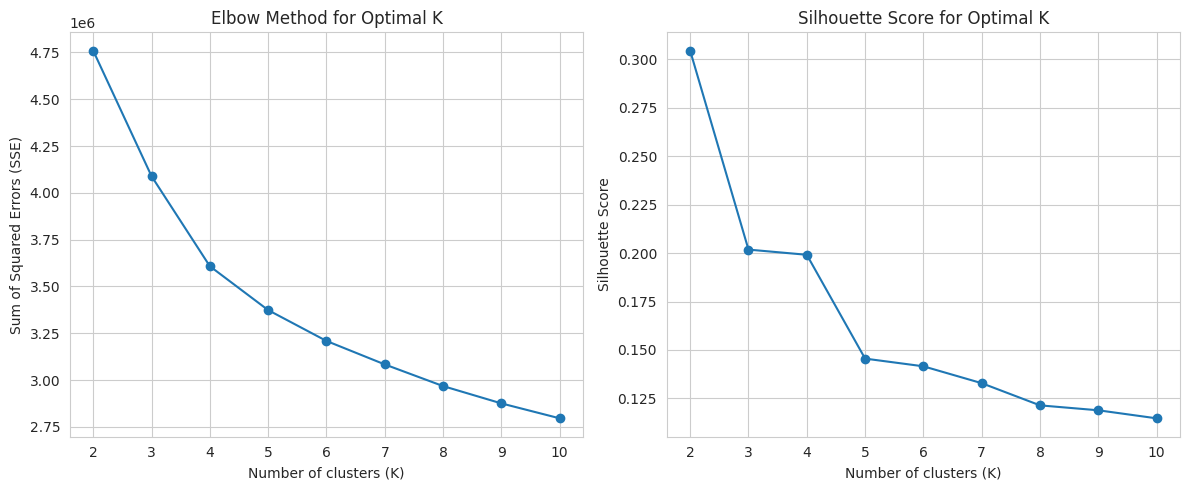

Elbow Method and Silhouette Score plots generated.


In [50]:
sse = [] # Sum of squared distances
silhouette_scores = []
max_k = 10 # Test up to 10 clusters

print("Calculating SSE and Silhouette Scores for different numbers of clusters...")

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    labels = kmeans.labels_
    # Calculate silhouette score only if there's more than one cluster and all clusters have at least one point
    if len(np.unique(labels)) > 1:
        # Using a sample_size to speed up calculation for large datasets
        silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=10000))
    else:
        silhouette_scores.append(0) # Or np.nan, or handle as appropriate

# Plotting the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_k + 1), sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(range(2, max_k + 1))
plt.grid(True)

# Plotting the Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

print("Elbow Method and Silhouette Score plots generated.")

### Applying K-Means Clustering

Based on the elbow method and silhouette score, let's select an optimal number of clusters (e.g., K=3 or K=4 often appear as reasonable choices for demonstration, but a deeper analysis might be needed). For this example, let's proceed with `K=4` clusters. We will then add the cluster labels back to our DataFrame and examine the characteristics of each cluster.

In [51]:
optimal_k = 4 # Choose K based on the plots above (e.g., from the elbow point or highest silhouette score)

print(f"Applying K-Means with {optimal_k} clusters...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original (filtered) dataframe
df_filtered_for_categories['cluster'] = cluster_labels

print(f"Clusters created. Distribution of cluster sizes:")
display(df_filtered_for_categories['cluster'].value_counts().sort_index())

print("\nCharacterizing clusters...")
# Characterize each cluster by calculating the mean of the original (unscaled) features
# Use df_filtered_for_categories with the added cluster column and original feature names (before scaling).
cluster_means = df_filtered_for_categories.groupby('cluster')[clustering_features + ['fantasy_points']].mean()
display(cluster_means.sort_values(by='fantasy_points'))

print("\nComparison of Clusters with Pre-defined Performance Categories:")
crosstab_clusters_performance = pd.crosstab(df_filtered_for_categories['cluster'], df_filtered_for_categories['player_performance_category'])
display(crosstab_clusters_performance)

Applying K-Means with 4 clusters...
Clusters created. Distribution of cluster sizes:


,count
cluster,
0,102149
1,104178
2,39613
3,35224



Characterizing clusters...


,ast_last10,ast_last5,ast_season_avg,blk_last10,blk_last5,blk_season_avg,days_rest,fantasy_points_last10,fantasy_points_last5,fantasy_points_season_avg,...,reb_last10,reb_last5,reb_season_avg,stl_last10,stl_last5,stl_season_avg,tov_last10,tov_last5,tov_season_avg,fantasy_points
cluster,,,,,,,,,,,,,,,,,,,,,
1,0.962944,0.946148,1.026620,0.276110,0.271117,0.310382,2.916575,10.790723,10.611351,11.661874,...,2.458183,2.427395,2.628348,0.390790,0.377926,0.434669,0.604105,0.592353,0.681440,11.584797
0,2.469946,2.478200,2.320320,0.348400,0.342442,0.355264,2.343030,22.105633,22.167047,21.016605,...,3.850807,3.854119,3.743840,0.874940,0.885412,0.838464,1.287336,1.289992,1.316411,21.763512
3,1.861302,1.870174,1.501333,1.274794,1.307493,1.247802,2.371735,29.489784,29.760296,26.895164,...,8.186674,8.269036,7.501924,0.736514,0.735725,0.699918,1.492814,1.496347,1.453684,28.895583
2,5.894476,5.939629,4.876220,0.485173,0.484360,0.462706,2.394542,40.724315,40.958445,35.137794,...,5.678112,5.694984,5.156279,1.227406,1.239115,1.189509,2.754713,2.778208,2.479650,40.141418



Comparison of Clusters with Pre-defined Performance Categories:


player_performance_category,above_average_performance,below_average_performance,high_performance,low_performance
cluster,,,,
0,34417,31754,21902,14076
1,15822,33471,4383,50502
2,7304,2210,29690,409
3,11472,6833,14935,1984


### Visualizing Clusters with PCA

To visualize the clusters, we'll reduce the dimensionality of our feature space to 2D using Principal Component Analysis (PCA) and then plot the clusters.

Performing PCA for visualization...


/tmp/ipykernel_104408/1690574715.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


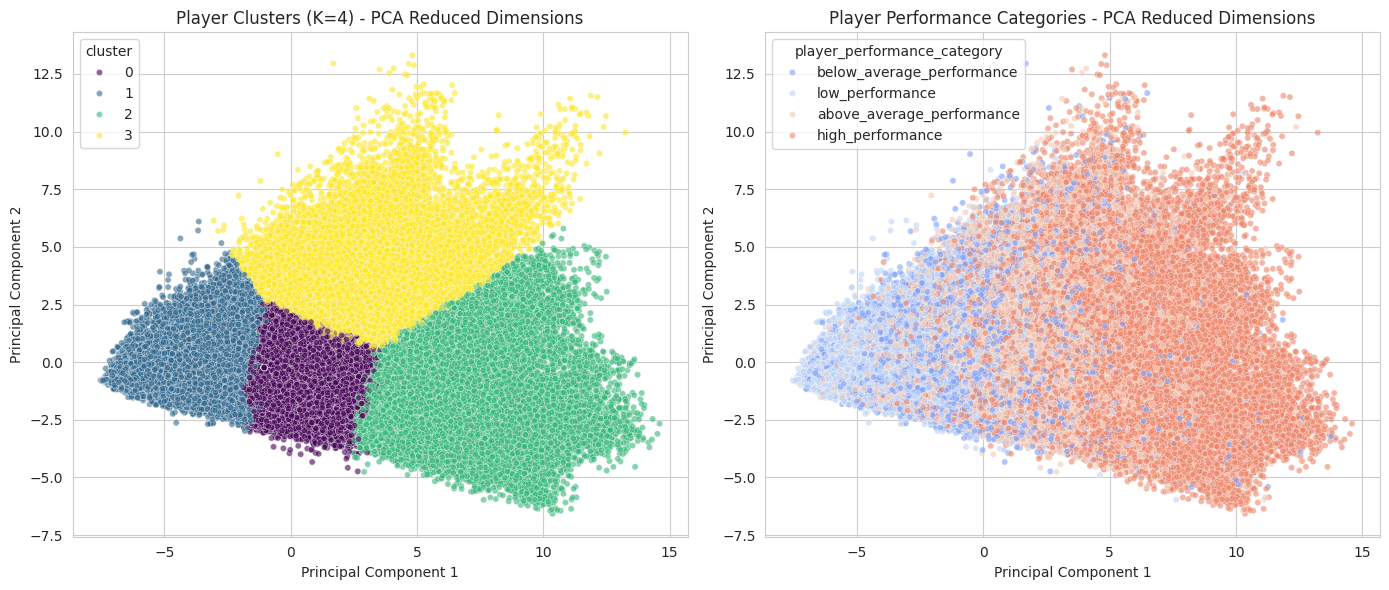

PCA plots generated for clusters and performance categories.


In [52]:
from sklearn.decomposition import PCA

print("Performing PCA for visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to a temporary DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = cluster_labels
df_pca['player_performance_category'] = df_filtered_for_categories['player_performance_category'].reset_index(drop=True)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1', y='PC2', hue='cluster', data=df_pca,
    palette='viridis', legend='full', alpha=0.6, s=20
)
plt.title(f'Player Clusters (K={optimal_k}) - PCA Reduced Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1', y='PC2', hue='player_performance_category', data=df_pca,
    palette='coolwarm', legend='full', alpha=0.6, s=20
)
plt.title('Player Performance Categories - PCA Reduced Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.tight_layout()
plt.show()

print("PCA plots generated for clusters and performance categories.")

In [53]:
print("Explained variance ratio of the principal components:")
print(pca.explained_variance_ratio_)

print("\nPrincipal Components (Loadings):")
# Display the components, which are the eigenvectors
# Each row is a principal component, and columns are the original features
pc_df = pd.DataFrame(pca.components_, columns=clustering_features, index=['PC1', 'PC2'])
display(pc_df)

Explained variance ratio of the principal components:
[0.49870201 0.15140942]

Principal Components (Loadings):


,ast_last10,ast_last5,ast_season_avg,blk_last10,blk_last5,blk_season_avg,days_rest,fantasy_points_last10,fantasy_points_last5,fantasy_points_season_avg,...,pts_season_avg,reb_last10,reb_last5,reb_season_avg,stl_last10,stl_last5,stl_season_avg,tov_last10,tov_last5,tov_season_avg
PC1,0.222120,0.216691,0.204872,0.106775,0.099165,0.103479,-0.047651,0.270145,0.264864,0.263386,...,0.245299,0.185446,0.180190,0.175967,0.179733,0.159755,0.203998,0.239453,0.225686,0.242528
PC2,-0.223687,-0.216947,-0.263889,0.401797,0.381664,0.415557,-0.015672,0.019785,0.023452,0.006130,...,-0.039403,0.311847,0.305842,0.309847,-0.099399,-0.089798,-0.141795,-0.083979,-0.078828,-0.100683


Let's break down the characteristics of each cluster based on the cluster_means data:

Cluster 0 (Moderate All-Around Players): This cluster represents players with moderate fantasy points (around 20-21 FP). They show decent contributions across various statistical categories like points (pts_season_avg ~10), rebounds (reb_season_avg ~4), and assists (ast_season_avg ~2.3). Their playing time (min_season_avg ~23) is also moderate. They are not top-tier in any single category but contribute consistently.

Cluster 1 (Low-Volume Role Players): This is the largest cluster by count and generally represents players with the lowest average fantasy points (around 12-14 FP). They have low averages in most statistical categories, including points, rebounds, assists, and minutes played (min_season_avg ~18). These are likely players who play fewer minutes or have more specialized, lower-impact roles.

Cluster 2 (High-Impact Offensive Superstars): This cluster stands out with the highest average fantasy points (around 40-42 FP). These players excel in offensive categories such as points (pts_season_avg ~24-25) and assists (ast_season_avg ~4.8-5.8). They also play significantly more minutes (min_season_avg ~35). This cluster likely contains the league's primary scorers and playmakers.

Cluster 3 (Solid Contributors / Rebounding & Defensive Focus): Players in this cluster have above-average fantasy points (around 28-30 FP), higher than Cluster 0 but lower than Cluster 2. They show strong contributions in rebounds (reb_season_avg ~6-7) and blocks (blk_season_avg ~0.7-0.8), while also providing a good amount of points (pts_season_avg ~15-16). Their minutes played (min_season_avg ~28) are higher than Cluster 0 but lower than Cluster 2. This cluster likely represents players who are strong rebounders, interior defenders, or secondary scoring options.

In summary, the clusters effectively differentiate players based on their overall fantasy production and the specific statistical areas where they contribute most. Cluster 2 represents the elite, high-usage offensive players, while Cluster 1 consists of lower-end role players. Clusters 0 and 3 fall in between, with Cluster 3 showing a stronger emphasis on rebounding and defense, and Cluster 0 on more balanced, moderate contributions.

In [54]:
import numpy as np
import pandas as pd

print("--- Performing Overfitting Checks ---")

# Dictionary to store results for easy comparison
overfitting_results = {}

# --- Ridge Regression ---
print("\nRidge Regression:")
# Use the best tuned Ridge model for the subset
ridge_model_tuned_subset = ridge_grid_search_subset.best_estimator_

# Predict on training subset
train_preds_ridge = ridge_model_tuned_subset.predict(X_train_subset)
train_rmse_ridge = np.sqrt(((train_preds_ridge - y_train_subset) ** 2).mean())

# Predict on validation subset
val_preds_ridge = ridge_model_tuned_subset.predict(X_val_subset)
val_rmse_ridge = np.sqrt(((val_preds_ridge - y_val_subset) ** 2).mean())

overfitting_results['Ridge'] = {'Train RMSE': train_rmse_ridge, 'Validation RMSE': val_rmse_ridge}
print(f"  Train RMSE: {train_rmse_ridge:.2f} FP")
print(f"  Validation RMSE: {val_rmse_ridge:.2f} FP")

# --- Lasso Regression ---
print("\nLasso Regression:")
# Use the best tuned Lasso model for the subset
lasso_model_tuned_subset = lasso_grid_search_subset.best_estimator_

# Predict on training subset
train_preds_lasso = lasso_model_tuned_subset.predict(X_train_subset)
train_rmse_lasso = np.sqrt(((train_preds_lasso - y_train_subset) ** 2).mean())

# Predict on validation subset
val_preds_lasso = lasso_model_tuned_subset.predict(X_val_subset)
val_rmse_lasso = np.sqrt(((val_preds_lasso - y_val_subset) ** 2).mean())

overfitting_results['Lasso'] = {'Train RMSE': train_rmse_lasso, 'Validation RMSE': val_rmse_lasso}
print(f"  Train RMSE: {train_rmse_lasso:.2f} FP")
print(f"  Validation RMSE: {val_rmse_lasso:.2f} FP")

# --- LightGBM Regression ---
print("\nLightGBM Regression:")
# Use the best tuned LightGBM model for the subset
lgbm_model_tuned_subset = lgbm_grid_search_subset.best_estimator_

# Predict on training subset
train_preds_lgbm = lgbm_model_tuned_subset.predict(X_train_subset)
train_rmse_lgbm = np.sqrt(((train_preds_lgbm - y_train_subset) ** 2).mean())

# Predict on validation subset
val_preds_lgbm = lgbm_model_tuned_subset.predict(X_val_subset)
val_rmse_lgbm = np.sqrt(((val_preds_lgbm - y_val_subset) ** 2).mean())

overfitting_results['LightGBM'] = {'Train RMSE': train_rmse_lgbm, 'Validation RMSE': val_rmse_lgbm}
print(f"  Train RMSE: {train_rmse_lgbm:.2f} FP")
print(f"  Validation RMSE: {val_rmse_lgbm:.2f} FP")

# --- XGBoost Regression ---
print("\nXGBoost Regression:")
# Use the best tuned XGBoost model for the subset
xgb_model_tuned_subset = xgb_grid_search_subset.best_estimator_

# Predict on training subset
train_preds_xgb = xgb_model_tuned_subset.predict(X_train_subset)
train_rmse_xgb = np.sqrt(((train_preds_xgb - y_train_subset) ** 2).mean())

# Predict on validation subset
val_preds_xgb = xgb_model_tuned_subset.predict(X_val_subset)
val_rmse_xgb = np.sqrt(((val_preds_xgb - y_val_subset) ** 2).mean())

overfitting_results['XGBoost'] = {'Train RMSE': train_rmse_xgb, 'Validation RMSE': val_rmse_xgb}
print(f"  Train RMSE: {train_rmse_xgb:.2f} FP")
print(f"  Validation RMSE: {val_rmse_xgb:.2f} FP")

# --- Neural Network ---
print("\nNeural Network:")
# Use the best tuned Neural Network model for the subset
nn_model_tuned_subset = nn_grid_search_subset.best_estimator_

# Scale data for NN if not already scaled for the subset training
# Assuming scaler_nn_subset_tuned from cell 9e6de930 is the correct scaler for X_train_subset and X_val_subset
X_train_nn_scaled = scaler_nn_subset_tuned.transform(X_train_subset)
X_val_nn_scaled = scaler_nn_subset_tuned.transform(X_val_subset)

# Predict on training subset
train_preds_nn = nn_model_tuned_subset.predict(X_train_nn_scaled)
train_rmse_nn = np.sqrt(((train_preds_nn.flatten() - y_train_subset) ** 2).mean())

# Predict on validation subset
val_preds_nn = nn_model_tuned_subset.predict(X_val_nn_scaled)
val_rmse_nn = np.sqrt(((val_preds_nn.flatten() - y_val_subset) ** 2).mean())

overfitting_results['Neural Network'] = {'Train RMSE': train_rmse_nn, 'Validation RMSE': val_rmse_nn}
print(f"  Train RMSE: {train_rmse_nn:.2f} FP")
print(f"  Validation RMSE: {val_rmse_nn:.2f} FP")

# --- Naive Baseline ---
print("\nNaive Baseline (using fantasy_points_season_avg):")
# Train RMSE for naive baseline (it's the feature itself)
train_naive_preds = X_train_subset["fantasy_points_season_avg"]
valid_idx_train_naive = train_naive_preds.notna() & y_train_subset.notna()
train_rmse_naive = np.sqrt(((train_naive_preds[valid_idx_train_naive] - y_train_subset[valid_idx_train_naive]) ** 2).mean())

# Validation RMSE for naive baseline (already computed as naive_rmse_subset)
val_rmse_naive = naive_rmse_subset

overfitting_results['Naive Baseline'] = {'Train RMSE': train_rmse_naive, 'Validation RMSE': val_rmse_naive}
print(f"  Train RMSE: {train_rmse_naive:.2f} FP")
print(f"  Validation RMSE: {val_rmse_naive:.2f} FP")


print("\n--- Summary of Overfitting Checks ---")
overfitting_df = pd.DataFrame(overfitting_results).T
display(overfitting_df.round(2))

--- Performing Overfitting Checks ---

Ridge Regression:
  Train RMSE: 9.82 FP
  Validation RMSE: 10.12 FP

Lasso Regression:
  Train RMSE: 9.82 FP
  Validation RMSE: 10.12 FP

LightGBM Regression:
  Train RMSE: 9.72 FP
  Validation RMSE: 10.11 FP

XGBoost Regression:
  Train RMSE: 9.66 FP
  Validation RMSE: 10.11 FP

Neural Network:
  Train RMSE: 9.80 FP
  Validation RMSE: 10.11 FP

Naive Baseline (using fantasy_points_season_avg):
  Train RMSE: 11.51 FP
  Validation RMSE: 11.69 FP

--- Summary of Overfitting Checks ---


,Train RMSE,Validation RMSE
Ridge,9.82,10.12
Lasso,9.82,10.12
LightGBM,9.72,10.11
XGBoost,9.66,10.11
Neural Network,9.80,10.11
Naive Baseline,11.51,11.69


## Feature Importance Comparison by Player Performance Group

Now, let's examine which features each model deemed most important for predicting fantasy points, broken down by our defined player performance categories. This analysis will highlight if different models, or different player groups, rely on distinct sets of features.

In [60]:
import pandas as pd
import numpy as np

print("--- Detailed Feature Importance Comparison by Model and Performance Category ---")

# Assuming feature_importance_results is available from the previous cell's execution

for category, models_data in feature_importance_results.items():
    print(f"\n### {category.replace('_', ' ').title()} Performance Category ###")

    # Collect data for DataFrame
    data_for_df = []
    # Get all unique top features across all models for this category
    all_top_features = sorted(list(set(feature for model_data in models_data.values() for feature in model_data.keys())))

    # Prepare rows for the DataFrame: one row per feature
    for feature in all_top_features:
        row = {'Feature': feature}
        for model_name, importances_dict in models_data.items():
            row[f'{model_name} Importance'] = importances_dict.get(feature, np.nan) # Use NaN if feature not in top 5 for model
        data_for_df.append(row)

    category_df = pd.DataFrame(data_for_df)
    # Sort by the importance of the first model in the list for consistent ordering
    if not category_df.empty and models_data:
        first_model_col = f'{list(models_data.keys())[0]} Importance'
        category_df = category_df.sort_values(by=first_model_col, ascending=False, na_position='last')

    display(category_df.round(4))

    print("\n--- End of comparison for this category ---\n")

--- Detailed Feature Importance Comparison by Model and Performance Category ---

### Low Performance Performance Category ###


,Feature,Ridge Importance,Lasso Importance,LightGBM Importance,XGBoost Importance
6,min_last5,0.5103,0.5124,308.0,0.3508
1,days_rest,0.3039,0.3039,NaN,0.0709
8,pts_last5,0.1467,0.1768,NaN,0.0305
5,min_last10,0.1203,0.1178,NaN,NaN
9,reb_last10,0.1146,0.1187,NaN,NaN
0,blk_season_avg,NaN,NaN,326.0,NaN
2,fantasy_points_last10,NaN,NaN,NaN,0.0558
3,fantasy_points_last5,NaN,NaN,NaN,0.0435
4,games_played_this_season,NaN,NaN,385.0,NaN
7,opp_pts_allowed_avg10,NaN,NaN,371.0,NaN



--- End of comparison for this category ---


### Below Average Performance Performance Category ###


,Feature,Ridge Importance,Lasso Importance,LightGBM Importance,XGBoost Importance
5,min_last5,0.1613,0.1610,307.0,0.0328
8,pts_last10,0.1474,0.2025,NaN,0.0320
6,min_season_avg,0.1073,0.1054,NaN,NaN
1,fantasy_points_last10,0.1056,NaN,339.0,0.2911
9,reb_season_avg,0.0967,0.0887,NaN,NaN
0,ast_last10,NaN,0.1137,NaN,NaN
2,fantasy_points_last5,NaN,NaN,NaN,0.0371
3,games_played_this_season,NaN,NaN,332.0,NaN
4,min_last10,NaN,NaN,NaN,0.0305
7,opp_pts_allowed_avg10,NaN,NaN,412.0,NaN



--- End of comparison for this category ---


### Above Average Performance Performance Category ###


,Feature,Ridge Importance,Lasso Importance,LightGBM Importance,XGBoost Importance
7,pts_last10,0.2129,0.1657,NaN,0.0319
5,min_last5,0.1758,0.1730,330.0,NaN
0,fantasy_points_last10,0.1493,0.2282,309.0,0.3002
4,min_last10,0.1245,0.1213,NaN,NaN
2,fantasy_points_season_avg,0.1209,0.2332,NaN,NaN
1,fantasy_points_last5,NaN,NaN,337.0,0.0384
3,games_played_this_season,NaN,NaN,311.0,NaN
6,opp_pts_allowed_avg10,NaN,NaN,432.0,NaN
8,pts_season_avg,NaN,NaN,NaN,0.0333
9,tov_last10,NaN,NaN,NaN,0.0298



--- End of comparison for this category ---


### High Performance Performance Category ###


,Feature,Ridge Importance,Lasso Importance,LightGBM Importance,XGBoost Importance
4,min_last10,1.5100,1.5150,NaN,NaN
5,min_season_avg,1.4837,1.4853,NaN,NaN
8,pts_season_avg,1.4619,1.4494,NaN,NaN
0,fantasy_points_last10,1.4309,3.0155,418.0,0.6019
7,pts_last10,1.2876,NaN,NaN,NaN
1,fantasy_points_last5,NaN,NaN,314.0,0.0371
2,fantasy_points_season_avg,NaN,1.1234,307.0,0.0352
3,games_played_this_season,NaN,NaN,297.0,NaN
6,opp_pts_allowed_avg10,NaN,NaN,521.0,NaN
9,reb_season_avg,NaN,NaN,NaN,0.0183



--- End of comparison for this category ---

